In [49]:
# Define the task and sample random layouts with four well-separated targets.

import itertools
import numpy as np
import matplotlib.pyplot as plt

# Task definition.
START = np.array([0.5, 0.05], dtype=np.float64)

NUM_TARGETS = 4
TARGET_LOW = np.array([0.1, 0.2])
TARGET_HIGH = np.array([0.9, 0.9])

MIN_TARGET_SEPARATION = 0.12
MIN_START_DISTANCE = 0.15


def sample_layout(rng, max_attempts=10_000):
    """Sample one valid four-target layout."""
    for _ in range(max_attempts):
        targets = rng.uniform(
            low=TARGET_LOW,
            high=TARGET_HIGH,
            size=(NUM_TARGETS, 2),
        )

        pairwise_distances = np.linalg.norm(
            targets[:, None, :] - targets[None, :, :],
            axis=-1,
        )
        np.fill_diagonal(pairwise_distances, np.inf)

        start_distances = np.linalg.norm(
            targets - START,
            axis=1,
        )

        if (
            pairwise_distances.min() >= MIN_TARGET_SEPARATION
            and start_distances.min() >= MIN_START_DISTANCE
        ):
            return targets

    raise RuntimeError("Could not sample a valid layout.")

In [50]:
# Enumerates all possible visit orders for the four targets, finds the exact shortest route from the start through all targets, and verifies the solver with simple sanity checks.

ALL_ORDERS = np.array(
    list(itertools.permutations(range(NUM_TARGETS))),
    dtype=np.int64,
)


def solve_exact_shortest_path(targets, start=START):
    """
    Find the shortest open route:
    start -> visit all four targets -> stop.

    No return to the start is required.
    """
    targets = np.asarray(targets, dtype=np.float64)
    start = np.asarray(start, dtype=np.float64)

    if targets.shape != (NUM_TARGETS, 2):
        raise ValueError("targets must have shape (4, 2).")

    if start.shape != (2,):
        raise ValueError("start must have shape (2,).")

    if not np.isfinite(targets).all() or not np.isfinite(start).all():
        raise ValueError("All coordinates must be finite.")

    # Shape: (24 candidate orders, 4 targets, 2 coordinates).
    ordered_targets = targets[ALL_ORDERS]

    start_points = np.broadcast_to(
        start,
        (len(ALL_ORDERS), 1, 2),
    )

    candidate_routes = np.concatenate(
        [start_points, ordered_targets],
        axis=1,
    )

    segment_lengths = np.linalg.norm(
        np.diff(candidate_routes, axis=1),
        axis=-1,
    )
    candidate_lengths = segment_lengths.sum(axis=1)

    best_index = int(np.argmin(candidate_lengths))
    best_length = float(candidate_lengths[best_index])

    # Keep numerically tied optima for later inspection.
    tied_indices = np.flatnonzero(
        np.isclose(
            candidate_lengths,
            best_length,
            rtol=1e-10,
            atol=1e-12,
        )
    )

    return {
        "order": ALL_ORDERS[best_index].copy(),
        "route": candidate_routes[best_index].copy(),
        "length": best_length,
        "all_lengths": candidate_lengths.copy(),
        "optimal_orders": ALL_ORDERS[tied_indices].copy(),
    }


# A simple case with an obvious solution:
# visit four collinear points in increasing distance from the start.
check_targets = np.array([
    [0.0, 0.25],
    [0.0, 0.50],
    [0.0, 0.75],
    [0.0, 1.00],
])

check = solve_exact_shortest_path(
    check_targets,
    start=np.array([0.0, 0.0]),
)

np.testing.assert_allclose(check["length"], 1.0)
np.testing.assert_array_equal(check["order"], [0, 1, 2, 3])

# Relabeling the same targets must not change the optimal length.
permuted_check = solve_exact_shortest_path(
    check_targets[[2, 0, 3, 1]],
    start=np.array([0.0, 0.0]),
)
np.testing.assert_allclose(
    permuted_check["length"],
    check["length"],
)

print("Checks passed: known solution and target-label invariance.")
print(f"Candidate visit orders per layout: {len(ALL_ORDERS)}")

Checks passed: known solution and target-label invariance.
Candidate visit orders per layout: 24


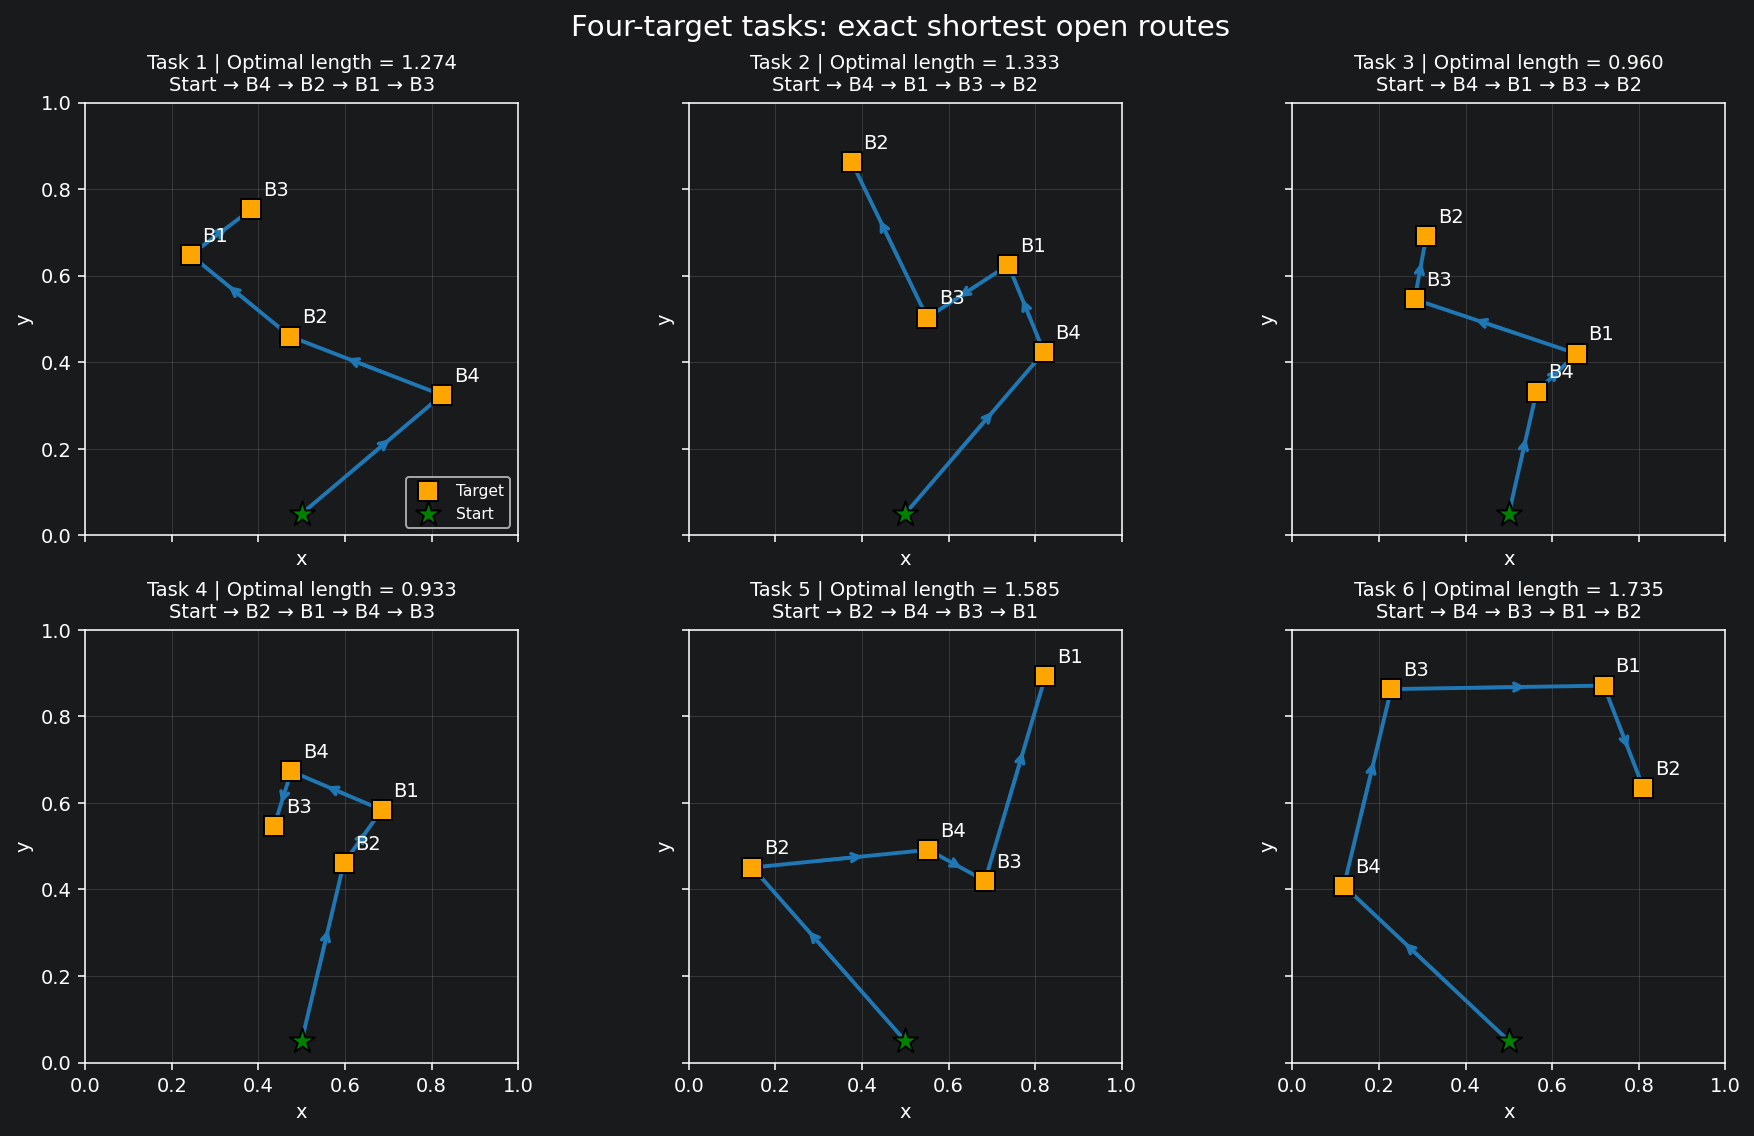

 Task   Optimal length          Visit order
    1         1.273826     4 -> 2 -> 1 -> 3
    2         1.332820     4 -> 1 -> 3 -> 2
    3         0.959728     4 -> 1 -> 3 -> 2
    4         0.933187     2 -> 1 -> 4 -> 3
    5         1.584611     2 -> 4 -> 3 -> 1
    6         1.735180     4 -> 3 -> 1 -> 2


In [51]:
# Samples six random four-target tasks, visualizes the exact shortest route for each one, and prints the corresponding optimal path length and visit order for quick inspection.

preview_rng = np.random.default_rng(2026)

preview_tasks = []

for _ in range(6):
    targets = sample_layout(preview_rng)
    solution = solve_exact_shortest_path(targets)

    preview_tasks.append({
        "targets": targets,
        "solution": solution,
    })


fig, axes = plt.subplots(
    2, 3,
    figsize=(13, 8),
    dpi=140,
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for task_index, (ax, task) in enumerate(
    zip(axes.flat, preview_tasks),
    start=1,
):
    targets = task["targets"]
    solution = task["solution"]
    route = solution["route"]

    ax.plot(
        route[:, 0],
        route[:, 1],
        color="tab:blue",
        linewidth=2,
        zorder=2,
    )

    # Direction arrows on each segment.
    for p0, p1 in zip(route[:-1], route[1:]):
        arrow_start = p0 + 0.35 * (p1 - p0)
        arrow_end = p0 + 0.65 * (p1 - p0)

        ax.annotate(
            "",
            xy=arrow_end,
            xytext=arrow_start,
            arrowprops={
                "arrowstyle": "->",
                "color": "tab:blue",
                "lw": 1.8,
            },
            zorder=3,
        )

    ax.scatter(
        targets[:, 0],
        targets[:, 1],
        marker="s",
        s=100,
        color="orange",
        edgecolor="black",
        zorder=4,
        label="Target",
    )

    ax.scatter(
        START[0],
        START[1],
        marker="*",
        s=180,
        color="green",
        edgecolor="black",
        zorder=5,
        label="Start",
    )

    for target_index, position in enumerate(targets, start=1):
        ax.annotate(
            f"B{target_index}",
            xy=position,
            xytext=(6, 7),
            textcoords="offset points",
            fontsize=10,
        )

    visit_order = " → ".join(
        f"B{i + 1}" for i in solution["order"]
    )

    ax.set_title(
        f"Task {task_index} | Optimal length = {solution['length']:.3f}\n"
        f"Start → {visit_order}",
        fontsize=10,
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(alpha=0.2)

axes[0, 0].legend(loc="lower right", fontsize=8)

fig.suptitle(
    "Four-target tasks: exact shortest open routes",
    fontsize=15,
)

plt.show()


print(f"{'Task':>5} {'Optimal length':>16} {'Visit order':>20}")
for index, task in enumerate(preview_tasks, start=1):
    solution = task["solution"]
    order_text = " -> ".join(
        str(i + 1) for i in solution["order"]
    )

    print(
        f"{index:>5} "
        f"{solution['length']:>16.6f} "
        f"{order_text:>20}"
    )

In [ ]:
def make_arc_length_expert(route):
    """Parameterize a polyline by normalized arc length."""
    route = np.asarray(route, dtype=np.float64)

    if route.shape != (5, 2):
        raise ValueError("route must contain the start and four targets.")

    if not np.isfinite(route).all():
        raise ValueError("route must contain finite coordinates.")

    segment_vectors = np.diff(route, axis=0)
    segment_lengths = np.linalg.norm(segment_vectors, axis=1)

    if np.any(segment_lengths <= 0):
        raise ValueError("Every segment must have positive length.")

    total_length = float(segment_lengths.sum())

    # Parameter values at the start and each target.
    knot_tau = np.concatenate([
        [0.0],
        np.cumsum(segment_lengths) / total_length,
    ])
    knot_tau[-1] = 1.0

    return {
        "route": route.copy(),
        "length": total_length,
        "knot_tau": knot_tau,
    }


def evaluate_arc_length_expert(expert, tau):
    """
    Return xi(tau) and dxi/dtau, each with shape (N, 2).

    tau is normalized distance along the path, not physical time.
    At internal corners, use the outgoing segment's derivative.
    At tau=1, use the final segment's derivative.
    """
    tau = np.asarray(tau, dtype=np.float64).reshape(-1)

    if not np.isfinite(tau).all():
        raise ValueError("tau must be finite.")

    if np.any((tau < 0.0) | (tau > 1.0)):
        raise ValueError("tau must lie in [0, 1].")

    route = expert["route"]
    knots = expert["knot_tau"]

    indices = np.searchsorted(knots, tau, side="right") - 1
    indices = np.clip(indices, 0, len(route) - 2)

    segment_vectors = route[indices + 1] - route[indices]
    parameter_widths = knots[indices + 1] - knots[indices]

    u = (tau - knots[indices]) / parameter_widths
    u = np.clip(u, 0.0, 1.0)

    positions = route[indices] + u[:, None] * segment_vectors

    # Derivative with respect to normalized path progress.
    derivatives = segment_vectors / parameter_widths[:, None]

    return positions, derivatives

In [ ]:
print(
    f"{'Task':>5} "
    f"{'Optimal length':>16} "
    f"{'Checked length':>16} "
    f"{'Max waypoint error':>20}"
)

for task_index, task in enumerate(preview_tasks, start=1):
    expert = make_arc_length_expert(task["solution"]["route"])
    task["arc_length_expert"] = expert

    # Every knot must coincide with its corresponding waypoint.
    waypoint_positions, _ = evaluate_arc_length_expert(
        expert, expert["knot_tau"]
    )

    waypoint_errors = np.linalg.norm(
        waypoint_positions - expert["route"], axis=1
    )

    np.testing.assert_allclose(
        waypoint_positions,
        expert["route"],
        atol=1e-12,
        rtol=0,
    )

    # Include all corners to avoid cutting across them when
    # measuring the length of the sampled polyline.
    probe_tau = np.unique(np.concatenate([
        np.linspace(0.0, 1.0, 2001),
        expert["knot_tau"],
    ]))

    positions, derivatives = evaluate_arc_length_expert(
        expert, probe_tau
    )

    checked_length = np.linalg.norm(
        np.diff(positions, axis=0), axis=1
    ).sum()

    np.testing.assert_allclose(
        checked_length,
        task["solution"]["length"],
        atol=1e-10,
        rtol=0,
    )

    # For normalized arc length, ||dxi/dtau|| equals total length
    # on each segment.
    np.testing.assert_allclose(
        np.linalg.norm(derivatives, axis=1),
        expert["length"],
        atol=1e-10,
        rtol=0,
    )

    print(
        f"{task_index:>5} "
        f"{task['solution']['length']:>16.6f} "
        f"{checked_length:>16.6f} "
        f"{waypoint_errors.max():>20.3e}"
    )

print("\nChecks passed: target visits and shortest-path length preserved.")

In [ ]:
task = preview_tasks[0]
expert = task["arc_length_expert"]
route = expert["route"]

sample_tau = np.linspace(0.0, 1.0, 61)
positions, _ = evaluate_arc_length_expert(expert, sample_tau)

fig, ax = plt.subplots(
    figsize=(7, 5.5),
    dpi=140,
    constrained_layout=True,
)

ax.plot(
    route[:, 0], route[:, 1],
    color="gray", linewidth=1.5, zorder=1,
)

scatter = ax.scatter(
    positions[:, 0], positions[:, 1],
    c=sample_tau, cmap="viridis", s=30, zorder=2,
)

ax.scatter(
    task["targets"][:, 0], task["targets"][:, 1],
    marker="s", s=100, color="orange",
    edgecolor="black", zorder=3,
)

ax.scatter(
    route[0, 0], route[0, 1],
    marker="*", s=180, color="green",
    edgecolor="black", zorder=4,
)

for visit_index, target_index in enumerate(
    task["solution"]["order"], start=1
):
    target = task["targets"][target_index]
    arrival_tau = expert["knot_tau"][visit_index]

    ax.annotate(
        f"B{target_index + 1}: τ={arrival_tau:.3f}",
        xy=target,
        xytext=(7, 8),
        textcoords="offset points",
        fontsize=9,
    )

fig.colorbar(
    scatter, ax=ax,
    label="Normalized distance along the path (τ)",
)

ax.set(
    title="Shortest expert path with arc-length parameterization",
    xlabel="x", ylabel="y",
    xlim=(0, 1), ylim=(0, 1),
)
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.2)

plt.show()

In [ ]:
# Builds the train, validation, and test task splits by generating random four-target layouts, computing the exact shortest expert route for each layout, and storing the scene conditions and expert-path information for later training and evaluation.

def build_task_split(num_layouts, seed):
    """Generate layouts and their exact expert paths."""
    rng = np.random.default_rng(seed)

    targets = np.empty((num_layouts, 4, 2), dtype=np.float64)
    orders = np.empty((num_layouts, 4), dtype=np.int64)
    routes = np.empty((num_layouts, 5, 2), dtype=np.float64)
    lengths = np.empty(num_layouts, dtype=np.float64)
    knot_tau = np.empty((num_layouts, 5), dtype=np.float64)

    for index in range(num_layouts):
        layout = sample_layout(rng)
        solution = solve_exact_shortest_path(layout)
        expert = make_arc_length_expert(solution["route"])

        # Keep the original target order in the scene description.
        targets[index] = layout

        # Expert information is stored separately.
        orders[index] = solution["order"]
        routes[index] = solution["route"]
        lengths[index] = solution["length"]
        knot_tau[index] = expert["knot_tau"]

    starts = np.broadcast_to(
        START, (num_layouts, 2)
    ).copy()

    # Scene condition:
    # [start_x, start_y, B1_x, B1_y, ..., B4_x, B4_y]
    conditions = np.concatenate(
        [starts, targets.reshape(num_layouts, -1)],
        axis=1,
    )

    return {
        "starts": starts,
        "targets": targets,
        "conditions": conditions,
        "orders": orders,
        "routes": routes,
        "lengths": lengths,
        "knot_tau": knot_tau,
    }


task_splits = {
    "train": build_task_split(10_000, seed=100),
    "validation": build_task_split(1_000, seed=200),
    "test": build_task_split(1_000, seed=300),
}

for name, split in task_splits.items():
    print(
        f"{name:>10}: "
        f"{len(split['targets']):>6} layouts | "
        f"condition shape={split['conditions'].shape} | "
        f"mean optimal length={split['lengths'].mean():.4f}"
    )

In [ ]:
def layout_key(targets):
    """Canonical key independent of target labels."""
    targets = np.round(targets, decimals=10)
    order = np.lexsort((targets[:, 1], targets[:, 0]))
    return tuple(targets[order].ravel())


split_keys = {}

for name, split in task_splits.items():
    keys = {layout_key(layout) for layout in split["targets"]}

    if len(keys) != len(split["targets"]):
        raise AssertionError(f"Duplicate layouts within {name}.")

    split_keys[name] = keys

for name_a, name_b in [
    ("train", "validation"),
    ("train", "test"),
    ("validation", "test"),
]:
    overlap = split_keys[name_a] & split_keys[name_b]

    if overlap:
        raise AssertionError(
            f"Overlapping layouts: {name_a} and {name_b}."
        )

print("Checks passed: no duplicate layouts within or across splits.")

In [ ]:
# Run once after creating a dataset for the first time; skip this step when restoring existing data.

from pathlib import Path
import json

dataset_dir = Path(
    "/home/matcho/projects/streaming-flow-policy"
    "/experiments/four_boxes_experiments/four_targets/datasets/v1"
)

dataset_dir.mkdir(parents=True, exist_ok=True)

config = {
    "dataset_version": 1,
    "task": "four_point_targets_shortest_open_path",
    "num_targets": NUM_TARGETS,
    "start": START.tolist(),
    "target_low": TARGET_LOW.tolist(),
    "target_high": TARGET_HIGH.tolist(),
    "min_target_separation": MIN_TARGET_SEPARATION,
    "min_start_distance": MIN_START_DISTANCE,
    "return_to_start": False,
    "obstacles": False,
    "expert_solver": "exhaustive_enumeration_of_24_orders",
    "parameterization": "normalized_arc_length",
    "condition_order": [
        "start_x", "start_y",
        "B1_x", "B1_y",
        "B2_x", "B2_y",
        "B3_x", "B3_y",
        "B4_x", "B4_y",
    ],
    "split_seeds": {
        "train": 100,
        "validation": 200,
        "test": 300,
    },
    "split_sizes": {
        name: len(split["targets"])
        for name, split in task_splits.items()
    },
    "numpy_version": np.__version__,
}

output_paths = [
    dataset_dir / f"{name}.npz"
    for name in task_splits
] + [dataset_dir / "config.json"]

existing = [path.name for path in output_paths if path.exists()]
if existing:
    raise FileExistsError(
        f"Files already exist: {existing}. "
        "Load the existing dataset, or choose a new version directory."
    )

for name, split in task_splits.items():
    path = dataset_dir / f"{name}.npz"
    np.savez_compressed(path, **split)

    # Confirm that saved arrays can be restored exactly.
    with np.load(path, allow_pickle=False) as restored:
        assert set(restored.files) == set(split)
        for key, values in split.items():
            np.testing.assert_array_equal(restored[key], values)

    print(f"Saved and verified: {path.name}")

with (dataset_dir / "config.json").open(
    "w", encoding="utf-8"
) as file:
    json.dump(config, file, indent=2)

print(f"\nDataset saved to: {dataset_dir}")

In [ ]:
# Restore existing data after restarting; skip dataset generation and saving when running this cell.

from pathlib import Path
import json
import numpy as np

dataset_dir = Path(
    "/home/matcho/projects/streaming-flow-policy"
    "/experiments/four_boxes_experiments/four_targets/datasets/v1"
)

with (dataset_dir / "config.json").open(
    encoding="utf-8"
) as file:
    dataset_config = json.load(file)

task_splits = {}

for name in ["train", "validation", "test"]:
    with np.load(
        dataset_dir / f"{name}.npz",
        allow_pickle=False,
    ) as data:
        task_splits[name] = {
            key: data[key].copy()
            for key in data.files
        }

print("Loaded:", {
    name: len(split["targets"])
    for name, split in task_splits.items()
})

In [ ]:
SIGMA_0 = 0.05
STABILIZING_GAIN = 2.5


def sample_flow_matching_batch(
    split,
    batch_size,
    rng,
    sigma_0=SIGMA_0,
    stabilizing_gain=STABILIZING_GAIN,
):
    """
    Generate conditional flow-matching samples.

    Input:
        [a_x, a_y, tau,
         start_x, start_y,
         B1_x, B1_y, ..., B4_x, B4_y]

    Target:
        dxi/dtau - k * (a - xi)

    Optimal visit orders and path lengths are NOT model inputs.
    """
    if batch_size <= 0:
        raise ValueError("batch_size must be positive.")

    num_layouts = len(split["targets"])

    layout_indices = rng.integers(
        0, num_layouts, size=batch_size
    )
    tau = rng.uniform(0.0, 1.0, size=batch_size)

    routes = split["routes"][layout_indices]       # (B, 5, 2)
    knots = split["knot_tau"][layout_indices]      # (B, 5)

    # At internal knots, select the outgoing segment.
    segment_indices = np.sum(
        tau[:, None] >= knots[:, 1:],
        axis=1,
    )
    segment_indices = np.clip(segment_indices, 0, 3)

    rows = np.arange(batch_size)

    p0 = routes[rows, segment_indices]
    p1 = routes[rows, segment_indices + 1]

    tau0 = knots[rows, segment_indices]
    tau1 = knots[rows, segment_indices + 1]
    interval = tau1 - tau0

    progress = (tau - tau0) / interval

    expert_positions = (
        p0 + progress[:, None] * (p1 - p0)
    )
    expert_derivatives = (
        (p1 - p0) / interval[:, None]
    )

    # Gaussian marginal of the stabilizing conditional flow.
    sigma_tau = sigma_0 * np.exp(-stabilizing_gain * tau)
    noise = rng.standard_normal((batch_size, 2))

    offsets = sigma_tau[:, None] * noise
    actions = expert_positions + offsets

    target_velocities = (
        expert_derivatives - stabilizing_gain * offsets
    )

    # Original box-label order, not the optimal visit order.
    conditions = split["conditions"][layout_indices]

    inputs = np.concatenate(
        [actions, tau[:, None], conditions],
        axis=1,
    ).astype(np.float32)

    targets = target_velocities.astype(np.float32)

    return {
        "inputs": inputs,
        "targets": targets,
        "layout_indices": layout_indices,
        "tau": tau,
        "actions": actions,
        "expert_positions": expert_positions,
        "expert_derivatives": expert_derivatives,
    }

In [ ]:
probe_batch = sample_flow_matching_batch(
    split=task_splits["train"],
    batch_size=2048,
    rng=np.random.default_rng(400),
)

assert probe_batch["inputs"].shape == (2048, 13)
assert probe_batch["targets"].shape == (2048, 2)

assert np.isfinite(probe_batch["inputs"]).all()
assert np.isfinite(probe_batch["targets"]).all()

# Check that model conditions contain only the saved scene description.
np.testing.assert_array_equal(
    probe_batch["inputs"][:, 3:],
    task_splits["train"]["conditions"][
        probe_batch["layout_indices"]
    ].astype(np.float32),
)

# Compare the vectorized interpolation with the earlier evaluator.
for row in range(32):
    layout_index = probe_batch["layout_indices"][row]

    expert = {
        "route": task_splits["train"]["routes"][layout_index],
        "knot_tau": task_splits["train"]["knot_tau"][layout_index],
    }

    positions, derivatives = evaluate_arc_length_expert(
        expert,
        [probe_batch["tau"][row]],
    )

    np.testing.assert_allclose(
        probe_batch["expert_positions"][row],
        positions[0],
        atol=1e-12,
        rtol=0,
    )
    np.testing.assert_allclose(
        probe_batch["expert_derivatives"][row],
        derivatives[0],
        atol=1e-12,
        rtol=0,
    )

print("Input shape:", probe_batch["inputs"].shape)
print("Target shape:", probe_batch["targets"].shape)
print("Checks passed: scene conditions and expert interpolation.")

row = 0
print("\nOne training example:")
print("Layout index:", probe_batch["layout_indices"][row])
print("Flow state a:", probe_batch["actions"][row])
print("Path parameter tau:", probe_batch["tau"][row])
print("Scene condition c:", probe_batch["inputs"][row, 3:])
print("Target derivative:", probe_batch["targets"][row])

In [ ]:
import copy
import random
import torch
from torch import nn

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


def set_training_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


class ConditionalVelocityMLP(nn.Module):
    """
    Input:  (a_x, a_y, tau, scene condition) — 13 dimensions.
    Output: derivative with respect to tau — 2 dimensions.
    """

    def __init__(self):
        super().__init__()

        layers = []
        input_dim = 13

        for _ in range(4):
            layers.extend([
                nn.Linear(input_dim, 128),
                nn.SiLU(),
            ])
            input_dim = 128

        layers.append(nn.Linear(input_dim, 2))
        self.network = nn.Sequential(*layers)

    def forward(self, inputs):
        normalized_inputs = 2.0 * inputs - 1.0
        return self.network(normalized_inputs)


# Fixed probes from validation layouts only.
# Keeping them fixed makes epoch-to-epoch comparisons consistent.
validation_probe_seed = 500

validation_probe = sample_flow_matching_batch(
    split=task_splits["validation"],
    batch_size=20_000,
    rng=np.random.default_rng(validation_probe_seed),
)

validation_inputs = torch.from_numpy(
    validation_probe["inputs"]
).to(device=device, dtype=torch.float32)

validation_targets = torch.from_numpy(
    validation_probe["targets"]
).to(device=device, dtype=torch.float32)

print("Validation inputs:", tuple(validation_inputs.shape))
print("Validation targets:", tuple(validation_targets.shape))

In [ ]:
# Diagnostic task: fit one fixed training layout.
# Keep the original datasets intact.
single_layout_index = 0

single_layout_split = {
    key: values[single_layout_index:single_layout_index + 1].copy()
    for key, values in task_splits["train"].items()
}

# A held-out set of (tau, noise) samples from the SAME layout.
# This measures fitting within one task, not unseen-layout generalization.
single_layout_probe = sample_flow_matching_batch(
    split=single_layout_split,
    batch_size=20_000,
    rng=np.random.default_rng(1500),
)

print("Diagnostic layout index:", single_layout_index)
print("Targets:\n", single_layout_split["targets"][0])
print("Expert visit order:", single_layout_split["orders"][0] + 1)
print("Optimal length:", single_layout_split["lengths"][0])

In [ ]:
from pathlib import Path
import json

training_config = {
    "seed": 0,
    "num_epochs": 50,
    "steps_per_epoch": 100,
    "batch_size": 2048,
    "learning_rate": 1e-3,
    "weight_decay": 1e-6,
    "hidden_dim": 128,
    "num_hidden_layers": 4,
    "sigma_0": SIGMA_0,
    "stabilizing_gain": STABILIZING_GAIN,
    "validation_probe_seed": validation_probe_seed,
    "validation_probe_size": len(validation_inputs),
    "dataset_dir": str(dataset_dir),
}

run_dir = (
    dataset_dir.parent.parent
    / "runs"
    / "conditional_mlp_v1_seed0"
)
run_dir.mkdir(parents=True, exist_ok=True)

config_path = run_dir / "config.json"
latest_path = run_dir / "latest.pt"
best_path = run_dir / "best.pt"

if config_path.exists():
    saved_config = json.loads(config_path.read_text())
    if saved_config != training_config:
        raise ValueError(
            "This run directory contains a different configuration. "
            "Use a new run directory for a new experiment."
        )
else:
    config_path.write_text(
        json.dumps(training_config, indent=2),
        encoding="utf-8",
    )

set_training_seed(training_config["seed"])

model = ConditionalVelocityMLP().to(
    device=device, dtype=torch.float32
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=training_config["learning_rate"],
    weight_decay=training_config["weight_decay"],
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=training_config["num_epochs"],
)

loss_function = nn.MSELoss()

train_rng = np.random.default_rng(
    1_000 + training_config["seed"]
)

history = {
    "train_loss": [],
    "validation_loss": [],
}
best_validation_loss = float("inf")
best_epoch = None
start_epoch = 0

# Resume from the last completed epoch.
if latest_path.exists():
    checkpoint = torch.load(
        latest_path,
        map_location="cpu",
        weights_only=True,
    )

    model.load_state_dict(checkpoint["model"])
    optimizer.load_state_dict(checkpoint["optimizer"])
    scheduler.load_state_dict(checkpoint["scheduler"])

    train_rng.bit_generator.state = checkpoint["numpy_rng_state"]
    torch.set_rng_state(checkpoint["torch_rng_state"])

    if device.type == "cuda" and checkpoint["cuda_rng_states"]:
        torch.cuda.set_rng_state_all(checkpoint["cuda_rng_states"])

    history = checkpoint["history"]
    best_validation_loss = checkpoint["best_validation_loss"]
    best_epoch = checkpoint["best_epoch"]
    start_epoch = checkpoint["epoch"]

    print(f"Resuming after epoch {start_epoch}.")


def save_checkpoint_atomic(payload, path):
    temporary_path = path.with_suffix(".tmp")
    torch.save(payload, temporary_path)
    temporary_path.replace(path)


for epoch in range(
    start_epoch + 1,
    training_config["num_epochs"] + 1,
):
    model.train()
    train_loss_sum = 0.0

    for _ in range(training_config["steps_per_epoch"]):
        batch = sample_flow_matching_batch(
            split=task_splits["train"],
            batch_size=training_config["batch_size"],
            rng=train_rng,
        )

        inputs = torch.from_numpy(batch["inputs"]).to(device)
        targets = torch.from_numpy(batch["targets"]).to(device)

        optimizer.zero_grad(set_to_none=True)

        predictions = model(inputs)
        loss = loss_function(predictions, targets)

        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite training loss.")

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()

    train_loss = (
        train_loss_sum / training_config["steps_per_epoch"]
    )

    model.eval()
    validation_loss_sum = 0.0
    validation_batch_size = 4096

    with torch.no_grad():
        for offset in range(
            0, len(validation_inputs), validation_batch_size
        ):
            inputs = validation_inputs[
                offset:offset + validation_batch_size
            ]
            targets = validation_targets[
                offset:offset + validation_batch_size
            ]

            loss = loss_function(model(inputs), targets)

            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite validation loss.")

            validation_loss_sum += loss.item() * len(inputs)

    validation_loss = (
        validation_loss_sum / len(validation_inputs)
    )

    history["train_loss"].append(train_loss)
    history["validation_loss"].append(validation_loss)

    model_state = {
        name: tensor.detach().cpu().clone()
        for name, tensor in model.state_dict().items()
    }

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_epoch = epoch

        save_checkpoint_atomic(
            {
                "model": model_state,
                "epoch": epoch,
                "validation_loss": validation_loss,
                "config": training_config,
            },
            best_path,
        )

    scheduler.step()

    save_checkpoint_atomic(
        {
            "model": model_state,
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
            "epoch": epoch,
            "history": copy.deepcopy(history),
            "best_validation_loss": best_validation_loss,
            "best_epoch": best_epoch,
            "numpy_rng_state": train_rng.bit_generator.state,
            "torch_rng_state": torch.get_rng_state(),
            "cuda_rng_states": (
                torch.cuda.get_rng_state_all()
                if device.type == "cuda" else []
            ),
        },
        latest_path,
    )

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:>3}/{training_config['num_epochs']} | "
            f"train={train_loss:.6f} | "
            f"validation={validation_loss:.6f} | "
            f"best epoch={best_epoch}"
        )

# Restore the selected model for subsequent rollout evaluation.
best_checkpoint = torch.load(
    best_path,
    map_location="cpu",
    weights_only=True,
)
model.load_state_dict(best_checkpoint["model"])
model.eval()

print(
    f"\nBest validation loss: {best_validation_loss:.6f} "
    f"(epoch {best_epoch})"
)
print("Run directory:", run_dir)

In [ ]:
epochs = np.arange(1, len(history["train_loss"]) + 1)

fig, ax = plt.subplots(figsize=(7, 4), dpi=140)

ax.plot(
    epochs, history["train_loss"],
    label="Training — fresh samples",
)
ax.plot(
    epochs, history["validation_loss"],
    label="Validation — fixed samples",
)

ax.set(
    xlabel="Epoch",
    ylabel="MSE per derivative component",
    title="Conditional SFP — four-target shortest paths",
)
ax.set_yscale("log")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
import copy

num_validation_rollouts = min(
    100, len(task_splits["validation"]["targets"])
)
num_integration_steps = 1000

validation_subset = {
    key: values[:num_validation_rollouts]
    for key, values in task_splits["validation"].items()
}

# Evaluate a separate float64 copy.
rollout_model = copy.deepcopy(model).to(
    device=device, dtype=torch.float64
)
rollout_model.eval()


@torch.no_grad()
def generate_validation_paths(
    evaluation_model,
    split,
    num_steps=1000,
):
    conditions = torch.as_tensor(
        split["conditions"],
        dtype=torch.float64,
        device=device,
    )

    # Exact task starts: no initial noise in this diagnostic.
    actions = torch.as_tensor(
        split["starts"],
        dtype=torch.float64,
        device=device,
    ).clone()

    paths = [actions.cpu().numpy().copy()]
    dt = 1.0 / num_steps

    def velocity(current_actions, tau):
        tau_column = torch.full(
            (len(current_actions), 1),
            tau,
            dtype=current_actions.dtype,
            device=current_actions.device,
        )
        inputs = torch.cat(
            [current_actions, tau_column, conditions],
            dim=1,
        )
        return evaluation_model(inputs)

    for step in range(num_steps):
        tau = step * dt

        k1 = velocity(actions, tau)
        k2 = velocity(actions + 0.5 * dt * k1, tau + 0.5 * dt)
        k3 = velocity(actions + 0.5 * dt * k2, tau + 0.5 * dt)
        k4 = velocity(actions + dt * k3, min(tau + dt, 1.0))

        actions = actions + dt / 6.0 * (
            k1 + 2 * k2 + 2 * k3 + k4
        )

        if not torch.isfinite(actions).all():
            raise RuntimeError("Non-finite generated positions.")

        paths.append(actions.cpu().numpy().copy())

    return np.stack(paths, axis=1)


validation_paths = generate_validation_paths(
    rollout_model,
    validation_subset,
    num_steps=num_integration_steps,
)

print("Generated paths:", validation_paths.shape)

In [ ]:
VISIT_TOLERANCE = 0.02


def target_distances_to_path(path, targets):
    """Minimum distance from each target to the sampled polyline."""
    segment_starts = path[:-1]
    segment_vectors = np.diff(path, axis=0)
    squared_lengths = np.sum(segment_vectors**2, axis=1)

    offsets = targets[:, None, :] - segment_starts[None, :, :]

    projection = np.sum(
        offsets * segment_vectors[None, :, :],
        axis=-1,
    ) / np.maximum(squared_lengths[None, :], 1e-30)

    projection = np.clip(projection, 0.0, 1.0)

    closest_points = (
        segment_starts[None, :, :]
        + projection[:, :, None] * segment_vectors[None, :, :]
    )

    distances = np.linalg.norm(
        targets[:, None, :] - closest_points,
        axis=-1,
    )
    return distances.min(axis=1)


target_distances = np.stack([
    target_distances_to_path(path, targets)
    for path, targets in zip(
        validation_paths,
        validation_subset["targets"],
    )
])

visited = target_distances <= VISIT_TOLERANCE
visited_counts = visited.sum(axis=1)
all_visited = visited.all(axis=1)

generated_lengths = np.linalg.norm(
    np.diff(validation_paths, axis=1),
    axis=-1,
).sum(axis=1)

length_ratios = (
    generated_lengths / validation_subset["lengths"]
)

print(f"Validation layouts: {len(validation_paths)}")
print(f"Visit tolerance: {VISIT_TOLERANCE}")
print(f"All four approximately visited: {all_visited.mean():.1%}")
print(f"Mean targets visited: {visited_counts.mean():.2f} / 4")
print(
    "Mean worst-target distance per layout:",
    f"{target_distances.max(axis=1).mean():.6f}",
)

for count in range(5):
    print(
        f"Layouts visiting {count} targets:",
        int(np.sum(visited_counts == count)),
    )

if all_visited.any():
    print(
        "Median length / exact expert length "
        "(approximately complete paths only):",
        f"{np.median(length_ratios[all_visited]):.4f}",
    )
else:
    print("No approximately complete paths; length ratio not summarized.")

# Plot the first six layouts, without selecting by performance.
num_plots = min(6, len(validation_paths))

fig, axes = plt.subplots(
    2, 3,
    figsize=(13, 8),
    dpi=140,
    constrained_layout=True,
)

for index, ax in enumerate(axes.flat):
    if index >= num_plots:
        ax.axis("off")
        continue

    path = validation_paths[index]
    expert_route = validation_subset["routes"][index]
    targets = validation_subset["targets"][index]
    start = validation_subset["starts"][index]

    ax.plot(
        expert_route[:, 0], expert_route[:, 1],
        "--", color="gray", linewidth=1.5,
        label="Exact expert",
    )
    ax.plot(
        path[:, 0], path[:, 1],
        color="tab:blue", linewidth=2,
        label="Learned",
    )

    for target_index, target in enumerate(targets):
        color = (
            "tab:green" if visited[index, target_index]
            else "tab:red"
        )

        ax.add_patch(plt.Circle(
            target,
            VISIT_TOLERANCE,
            fill=False,
            color=color,
            alpha=0.7,
        ))
        ax.scatter(
            target[0], target[1],
            marker="s", s=65,
            color=color, edgecolor="black", zorder=4,
        )
        ax.annotate(
            f"B{target_index + 1}",
            target,
            xytext=(6, 7),
            textcoords="offset points",
            fontsize=9,
        )

    ax.scatter(
        start[0], start[1],
        marker="*", s=150, color="gold",
        edgecolor="black", zorder=5,
    )
    ax.scatter(
        path[-1, 0], path[-1, 1],
        marker="x", s=65, color="tab:blue", zorder=5,
    )

    ax.set_title(
        f"Validation {index + 1}: "
        f"{visited_counts[index]}/4 targets visited\n"
        f"Length ratio = {length_ratios[index]:.3f}"
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.2)
    ax.margins(0.12)

axes[0, 0].legend(fontsize=8)
plt.show()

In [ ]:
# The exact expert routes must visit all four targets.
expert_target_distances = np.stack([
    target_distances_to_path(route, targets)
    for route, targets in zip(
        validation_subset["routes"],
        validation_subset["targets"],
    )
])

expert_all_visited = (
    expert_target_distances <= VISIT_TOLERANCE
).all(axis=1)

expert_measured_lengths = np.linalg.norm(
    np.diff(validation_subset["routes"], axis=1),
    axis=-1,
).sum(axis=1)

np.testing.assert_allclose(
    expert_target_distances,
    0.0,
    atol=1e-12,
    rtol=0,
)

np.testing.assert_allclose(
    expert_measured_lengths,
    validation_subset["lengths"],
    atol=1e-12,
    rtol=0,
)

print(
    "Exact expert: all four visited:",
    f"{expert_all_visited.mean():.1%}",
)
print("Checks passed: expert visits and stored optimal lengths.")

In [ ]:
num_train_rollouts = min(
    len(validation_paths),
    len(task_splits["train"]["targets"]),
)

# Fixed random subset of training layouts.
train_diagnostic_indices = np.random.default_rng(600).choice(
    len(task_splits["train"]["targets"]),
    size=num_train_rollouts,
    replace=False,
)

train_diagnostic_subset = {
    key: values[train_diagnostic_indices]
    for key, values in task_splits["train"].items()
}

train_diagnostic_paths = generate_validation_paths(
    rollout_model,
    train_diagnostic_subset,
    num_steps=num_integration_steps,
)


def summarize_path_visits(paths, split, tolerance):
    distances = np.stack([
        target_distances_to_path(path, targets)
        for path, targets in zip(paths, split["targets"])
    ])

    counts = (distances <= tolerance).sum(axis=1)

    return {
        "all_visited_rate": np.mean(counts == 4),
        "mean_visited": counts.mean(),
        "mean_worst_distance": distances.max(axis=1).mean(),
        "counts": counts,
        "distances": distances,
    }


train_visit_summary = summarize_path_visits(
    train_diagnostic_paths,
    train_diagnostic_subset,
    VISIT_TOLERANCE,
)

validation_visit_summary = summarize_path_visits(
    validation_paths,
    validation_subset,
    VISIT_TOLERANCE,
)

print(
    f"{'Layouts':>12} "
    f"{'All 4 visited':>15} "
    f"{'Mean visited':>15} "
    f"{'Mean worst dist':>18}"
)

for name, result in [
    ("Training", train_visit_summary),
    ("Validation", validation_visit_summary),
]:
    print(
        f"{name:>12} "
        f"{result['all_visited_rate']:>14.1%} "
        f"{result['mean_visited']:>12.2f}/4 "
        f"{result['mean_worst_distance']:>18.6f}"
    )

    print(
        "    Layout counts for visiting 0/1/2/3/4 targets:",
        np.bincount(result["counts"], minlength=5).tolist(),
    )

In [ ]:
@torch.no_grad()
def diagnose_velocity_fit(
    paths,
    split,
    evaluation_model,
    num_probes=200,
):
    num_layouts, num_saved_points, _ = paths.shape

    # Probe segment midpoints of the saved rollout discretization.
    # Avoid endpoints and reduce the chance of probing an expert corner.
    probe_indices = np.unique(
        np.linspace(
            0,
            num_saved_points - 2,
            num_probes,
        ).round().astype(int)
    )

    tau = (
        probe_indices + 0.5
    ) / (num_saved_points - 1)

    # Approximate rollout positions at these midpoints.
    rollout_positions = 0.5 * (
        paths[:, probe_indices, :]
        + paths[:, probe_indices + 1, :]
    )

    expert_positions = []
    expert_derivatives = []

    for layout_index in range(num_layouts):
        expert = {
            "route": split["routes"][layout_index],
            "knot_tau": split["knot_tau"][layout_index],
        }

        positions, derivatives = evaluate_arc_length_expert(
            expert, tau
        )

        expert_positions.append(positions)
        expert_derivatives.append(derivatives)

    expert_positions = np.stack(expert_positions)
    expert_derivatives = np.stack(expert_derivatives)

    def predict(actions):
        tau_inputs = np.broadcast_to(
            tau[None, :, None],
            (num_layouts, len(tau), 1),
        )
        conditions = np.broadcast_to(
            split["conditions"][:, None, :],
            (num_layouts, len(tau), split["conditions"].shape[1]),
        )

        inputs = np.concatenate(
            [actions, tau_inputs, conditions],
            axis=-1,
        ).reshape(-1, 13)

        parameter = next(evaluation_model.parameters())
        predictions = []

        for offset in range(0, len(inputs), 4096):
            batch = torch.as_tensor(
                inputs[offset:offset + 4096],
                dtype=parameter.dtype,
                device=parameter.device,
            )
            predictions.append(
                evaluation_model(batch).cpu().numpy()
            )

        return np.concatenate(predictions).reshape(
            num_layouts, len(tau), 2
        )

    # On the expert path, the stabilization term is zero.
    expert_predictions = predict(expert_positions)

    # On learned rollouts, compare with the full stabilizing field.
    rollout_reference = (
        expert_derivatives
        - STABILIZING_GAIN
        * (rollout_positions - expert_positions)
    )
    rollout_predictions = predict(rollout_positions)

    def rmse(values):
        return float(np.sqrt(np.mean(values**2)))

    return {
        "expert_rmse": rmse(
            expert_predictions - expert_derivatives
        ),
        "rollout_rmse": rmse(
            rollout_predictions - rollout_reference
        ),
        "expert_reference_rms": rmse(expert_derivatives),
        "rollout_reference_rms": rmse(rollout_reference),
    }


velocity_diagnostics = {}

for name, paths, split in [
    (
        "Training",
        train_diagnostic_paths,
        train_diagnostic_subset,
    ),
    (
        "Validation",
        validation_paths,
        validation_subset,
    ),
]:
    result = diagnose_velocity_fit(
        paths,
        split,
        rollout_model,
    )
    velocity_diagnostics[name] = result

    print(f"\n{name} layouts")
    print(
        "  Expert-path velocity RMSE: "
        f"{result['expert_rmse']:.6f}"
    )
    print(
        "  Learned-path velocity RMSE: "
        f"{result['rollout_rmse']:.6f}"
    )
    print(
        "  Reference RMS, expert / learned paths: "
        f"{result['expert_reference_rms']:.6f} / "
        f"{result['rollout_reference_rms']:.6f}"
    )

In [34]:
validation_inputs = torch.from_numpy(
    single_layout_probe["inputs"]
).to(device=device, dtype=torch.float32)

validation_targets = torch.from_numpy(
    single_layout_probe["targets"]
).to(device=device, dtype=torch.float32)

from pathlib import Path
import json

training_config = {
    "experiment": "single_layout_fit_check",
    "layout_index": single_layout_index,
    "seed": 0,
    "num_epochs": 50,
    "steps_per_epoch": 100,
    "batch_size": 2048,
    "learning_rate": 1e-3,
    "weight_decay": 1e-6,
    "hidden_dim": 128,
    "num_hidden_layers": 4,
    "sigma_0": SIGMA_0,
    "stabilizing_gain": STABILIZING_GAIN,
    "validation_probe_seed": 1500,
    "validation_probe_size": len(validation_inputs),
    "dataset_dir": str(dataset_dir),
}

run_dir = (
    dataset_dir.parent.parent
    / "runs"
    / "single_layout_fit_v1_seed0"
)
run_dir.mkdir(parents=True, exist_ok=True)

config_path = run_dir / "config.json"
latest_path = run_dir / "latest.pt"
best_path = run_dir / "best.pt"

if config_path.exists():
    saved_config = json.loads(config_path.read_text())
    if saved_config != training_config:
        raise ValueError(
            "This run directory contains a different configuration. "
            "Use a new run directory for a new experiment."
        )
else:
    config_path.write_text(
        json.dumps(training_config, indent=2),
        encoding="utf-8",
    )

set_training_seed(training_config["seed"])

model = ConditionalVelocityMLP().to(
    device=device, dtype=torch.float32
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=training_config["learning_rate"],
    weight_decay=training_config["weight_decay"],
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=training_config["num_epochs"],
)

loss_function = nn.MSELoss()

train_rng = np.random.default_rng(
    1_000 + training_config["seed"]
)

history = {
    "train_loss": [],
    "validation_loss": [],
}
best_validation_loss = float("inf")
best_epoch = None
start_epoch = 0

# Resume from the last completed epoch.
if latest_path.exists():
    checkpoint = torch.load(
        latest_path,
        map_location="cpu",
        weights_only=True,
    )

    model.load_state_dict(checkpoint["model"])
    optimizer.load_state_dict(checkpoint["optimizer"])
    scheduler.load_state_dict(checkpoint["scheduler"])

    train_rng.bit_generator.state = checkpoint["numpy_rng_state"]
    torch.set_rng_state(checkpoint["torch_rng_state"])

    if device.type == "cuda" and checkpoint["cuda_rng_states"]:
        torch.cuda.set_rng_state_all(checkpoint["cuda_rng_states"])

    history = checkpoint["history"]
    best_validation_loss = checkpoint["best_validation_loss"]
    best_epoch = checkpoint["best_epoch"]
    start_epoch = checkpoint["epoch"]

    print(f"Resuming after epoch {start_epoch}.")


def save_checkpoint_atomic(payload, path):
    temporary_path = path.with_suffix(".tmp")
    torch.save(payload, temporary_path)
    temporary_path.replace(path)


for epoch in range(
    start_epoch + 1,
    training_config["num_epochs"] + 1,
):
    model.train()
    train_loss_sum = 0.0

    for _ in range(training_config["steps_per_epoch"]):
        batch = sample_flow_matching_batch(
            split=single_layout_split,
            batch_size=training_config["batch_size"],
            rng=train_rng,
        )

        inputs = torch.from_numpy(batch["inputs"]).to(device)
        targets = torch.from_numpy(batch["targets"]).to(device)

        optimizer.zero_grad(set_to_none=True)

        predictions = model(inputs)
        loss = loss_function(predictions, targets)

        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite training loss.")

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()

    train_loss = (
        train_loss_sum / training_config["steps_per_epoch"]
    )

    model.eval()
    validation_loss_sum = 0.0
    validation_batch_size = 4096

    with torch.no_grad():
        for offset in range(
            0, len(validation_inputs), validation_batch_size
        ):
            inputs = validation_inputs[
                offset:offset + validation_batch_size
            ]
            targets = validation_targets[
                offset:offset + validation_batch_size
            ]

            loss = loss_function(model(inputs), targets)

            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite validation loss.")

            validation_loss_sum += loss.item() * len(inputs)

    validation_loss = (
        validation_loss_sum / len(validation_inputs)
    )

    history["train_loss"].append(train_loss)
    history["validation_loss"].append(validation_loss)

    model_state = {
        name: tensor.detach().cpu().clone()
        for name, tensor in model.state_dict().items()
    }

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_epoch = epoch

        save_checkpoint_atomic(
            {
                "model": model_state,
                "epoch": epoch,
                "validation_loss": validation_loss,
                "config": training_config,
            },
            best_path,
        )

    scheduler.step()

    save_checkpoint_atomic(
        {
            "model": model_state,
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
            "epoch": epoch,
            "history": copy.deepcopy(history),
            "best_validation_loss": best_validation_loss,
            "best_epoch": best_epoch,
            "numpy_rng_state": train_rng.bit_generator.state,
            "torch_rng_state": torch.get_rng_state(),
            "cuda_rng_states": (
                torch.cuda.get_rng_state_all()
                if device.type == "cuda" else []
            ),
        },
        latest_path,
    )

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:>3}/{training_config['num_epochs']} | "
            f"train={train_loss:.6f} | "
            f"validation={validation_loss:.6f} | "
            f"best epoch={best_epoch}"
        )

# Restore the selected model for subsequent rollout evaluation.
best_checkpoint = torch.load(
    best_path,
    map_location="cpu",
    weights_only=True,
)
model.load_state_dict(best_checkpoint["model"])
model.eval()

print(
    f"\nBest validation loss: {best_validation_loss:.6f} "
    f"(epoch {best_epoch})"
)
print("Run directory:", run_dir)

Resuming after epoch 50.

Best validation loss: 0.003488 (epoch 47)
Run directory: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/runs/single_layout_fit_v1_seed0


Targets visited: 4 / 4
Distance to each target: [0.0021061  0.00181281 0.00025121 0.00201707]
Expert-path velocity RMSE: 0.054472
Learned-path velocity RMSE: 0.053958


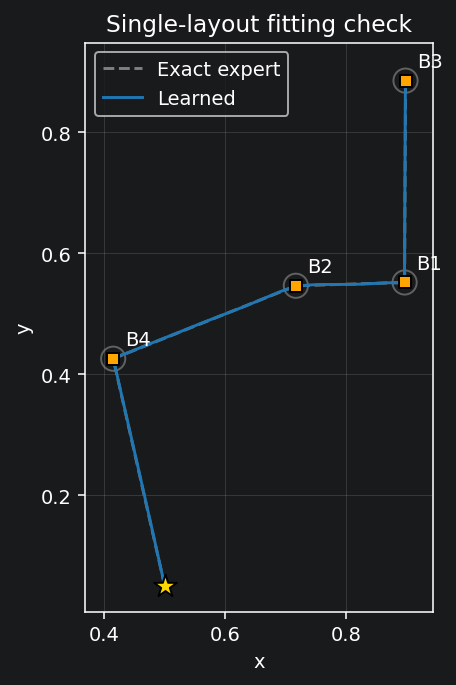

In [35]:
single_layout_model = copy.deepcopy(model).to(
    device=device, dtype=torch.float64
)
single_layout_model.eval()

single_layout_paths = generate_validation_paths(
    single_layout_model,
    single_layout_split,
    num_steps=num_integration_steps,
)

single_layout_summary = summarize_path_visits(
    single_layout_paths,
    single_layout_split,
    VISIT_TOLERANCE,
)

single_layout_velocity = diagnose_velocity_fit(
    single_layout_paths,
    single_layout_split,
    single_layout_model,
)

print(
    "Targets visited:",
    f"{single_layout_summary['counts'][0]} / 4",
)
print(
    "Distance to each target:",
    single_layout_summary["distances"][0],
)
print(
    "Expert-path velocity RMSE:",
    f"{single_layout_velocity['expert_rmse']:.6f}",
)
print(
    "Learned-path velocity RMSE:",
    f"{single_layout_velocity['rollout_rmse']:.6f}",
)

route = single_layout_split["routes"][0]
path = single_layout_paths[0]
targets = single_layout_split["targets"][0]

fig, ax = plt.subplots(figsize=(6, 5), dpi=140)

ax.plot(
    route[:, 0], route[:, 1],
    "--", color="gray", label="Exact expert",
)
ax.plot(
    path[:, 0], path[:, 1],
    color="tab:blue", label="Learned",
)
ax.scatter(
    targets[:, 0], targets[:, 1],
    marker="s", color="orange", edgecolor="black", zorder=4,
)
ax.scatter(
    route[0, 0], route[0, 1],
    marker="*", s=150, color="gold",
    edgecolor="black", zorder=5,
)

for index, target in enumerate(targets):
    ax.add_patch(plt.Circle(
        target, VISIT_TOLERANCE,
        fill=False, color="gray", alpha=0.7,
    ))
    ax.annotate(
        f"B{index + 1}", target,
        xytext=(6, 7), textcoords="offset points",
    )

ax.set(
    title="Single-layout fitting check",
    xlabel="x", ylabel="y",
)
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

In [36]:
from pathlib import Path
import copy
import json
import numpy as np
import torch

small_run_dir = (
    dataset_dir.parent.parent
    / "runs"
    / "sixteen_layout_fit_v1_seed0"
)
small_run_dir.mkdir(parents=True, exist_ok=True)

small_config = {
    "experiment": "sixteen_layout_fit_check",
    "dataset_dir": str(dataset_dir),
    "num_layouts": 16,
    "layout_selection_seed": 1600,
    "training_seed": 0,
    "train_sampling_seed": 1700,
    "validation_probe_seed": 1800,
    "validation_probe_size": 20_000,
    "num_epochs": 50,
    "steps_per_epoch": 100,
    "batch_size": 2048,
    "learning_rate": 1e-3,
    "weight_decay": 1e-6,
    "hidden_dim": 128,
    "num_hidden_layers": 4,
    "sigma_0": float(SIGMA_0),
    "stabilizing_gain": float(STABILIZING_GAIN),
}

config_path = small_run_dir / "config.json"
indices_path = small_run_dir / "layout_indices.npy"

if config_path.exists():
    stored_config = json.loads(
        config_path.read_text(encoding="utf-8")
    )
    if stored_config != small_config:
        raise ValueError(
            "Configuration differs from the existing run. "
            "Use a new run directory."
        )
else:
    config_path.write_text(
        json.dumps(small_config, indent=2),
        encoding="utf-8",
    )

expected_indices = np.random.default_rng(
    small_config["layout_selection_seed"]
).choice(
    len(task_splits["train"]["targets"]),
    size=small_config["num_layouts"],
    replace=False,
)

if indices_path.exists():
    small_indices = np.load(indices_path, allow_pickle=False)
    np.testing.assert_array_equal(small_indices, expected_indices)
else:
    small_indices = expected_indices
    np.save(indices_path, small_indices, allow_pickle=False)

small_train_split = {
    key: values[small_indices].copy()
    for key, values in task_splits["train"].items()
}

# Held-out (tau, noise) samples from the same 16 layouts.
# Used for checkpoint selection, not unseen-layout evaluation.
small_probe = sample_flow_matching_batch(
    split=small_train_split,
    batch_size=small_config["validation_probe_size"],
    rng=np.random.default_rng(
        small_config["validation_probe_seed"]
    ),
    sigma_0=small_config["sigma_0"],
    stabilizing_gain=small_config["stabilizing_gain"],
)

print("Selected training layout indices:")
print(small_indices)
print("Run directory:", small_run_dir)

Selected training layout indices:
[8621 5209 8093 6192 4171 2654 9987 6636 3334  242 4083 1469 8948 5774
  481 2782]
Run directory: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/runs/sixteen_layout_fit_v1_seed0


In [37]:
set_training_seed(small_config["training_seed"])

small_model = ConditionalVelocityMLP().to(
    device=device,
    dtype=torch.float32,
)

small_optimizer = torch.optim.AdamW(
    small_model.parameters(),
    lr=small_config["learning_rate"],
    weight_decay=small_config["weight_decay"],
)

small_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    small_optimizer,
    T_max=small_config["num_epochs"],
)

small_rng = np.random.default_rng(
    small_config["train_sampling_seed"]
)

probe_inputs = torch.from_numpy(
    small_probe["inputs"]
).to(device=device, dtype=torch.float32)

probe_targets = torch.from_numpy(
    small_probe["targets"]
).to(device=device, dtype=torch.float32)

small_history = {"train_loss": [], "probe_loss": []}
small_best_loss = float("inf")
small_best_epoch = None
small_start_epoch = 0

small_latest_path = small_run_dir / "latest.pt"
small_best_path = small_run_dir / "best.pt"

if small_latest_path.exists():
    checkpoint = torch.load(
        small_latest_path,
        map_location="cpu",
        weights_only=True,
    )

    small_model.load_state_dict(checkpoint["model"])
    small_optimizer.load_state_dict(checkpoint["optimizer"])
    small_scheduler.load_state_dict(checkpoint["scheduler"])

    small_rng.bit_generator.state = checkpoint["numpy_rng_state"]
    torch.set_rng_state(checkpoint["torch_rng_state"])

    if device.type == "cuda" and checkpoint["cuda_rng_states"]:
        torch.cuda.set_rng_state_all(checkpoint["cuda_rng_states"])

    small_history = checkpoint["history"]
    small_best_loss = checkpoint["best_loss"]
    small_best_epoch = checkpoint["best_epoch"]
    small_start_epoch = checkpoint["epoch"]

    print(f"Resuming after epoch {small_start_epoch}.")


def save_small_checkpoint(payload, path):
    temporary_path = path.with_suffix(".tmp")
    torch.save(payload, temporary_path)
    temporary_path.replace(path)


for epoch in range(
    small_start_epoch + 1,
    small_config["num_epochs"] + 1,
):
    small_model.train()
    train_loss_sum = 0.0

    for _ in range(small_config["steps_per_epoch"]):
        batch = sample_flow_matching_batch(
            split=small_train_split,
            batch_size=small_config["batch_size"],
            rng=small_rng,
            sigma_0=small_config["sigma_0"],
            stabilizing_gain=small_config["stabilizing_gain"],
        )

        inputs = torch.from_numpy(batch["inputs"]).to(device)
        targets = torch.from_numpy(batch["targets"]).to(device)

        small_optimizer.zero_grad(set_to_none=True)
        loss = torch.nn.functional.mse_loss(
            small_model(inputs), targets
        )

        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite training loss.")

        loss.backward()
        small_optimizer.step()
        train_loss_sum += loss.item()

    train_loss = (
        train_loss_sum / small_config["steps_per_epoch"]
    )

    small_model.eval()
    probe_loss_sum = 0.0

    with torch.no_grad():
        for offset in range(0, len(probe_inputs), 4096):
            inputs = probe_inputs[offset:offset + 4096]
            targets = probe_targets[offset:offset + 4096]

            loss = torch.nn.functional.mse_loss(
                small_model(inputs), targets
            )

            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite probe loss.")

            probe_loss_sum += loss.item() * len(inputs)

    probe_loss = probe_loss_sum / len(probe_inputs)

    small_history["train_loss"].append(train_loss)
    small_history["probe_loss"].append(probe_loss)

    state = {
        name: tensor.detach().cpu().clone()
        for name, tensor in small_model.state_dict().items()
    }

    if probe_loss < small_best_loss:
        small_best_loss = probe_loss
        small_best_epoch = epoch

        save_small_checkpoint(
            {
                "model": state,
                "epoch": epoch,
                "probe_loss": probe_loss,
                "config": small_config,
                "layout_indices": small_indices.tolist(),
            },
            small_best_path,
        )

    small_scheduler.step()

    save_small_checkpoint(
        {
            "model": state,
            "optimizer": small_optimizer.state_dict(),
            "scheduler": small_scheduler.state_dict(),
            "epoch": epoch,
            "history": copy.deepcopy(small_history),
            "best_loss": small_best_loss,
            "best_epoch": small_best_epoch,
            "numpy_rng_state": small_rng.bit_generator.state,
            "torch_rng_state": torch.get_rng_state(),
            "cuda_rng_states": (
                torch.cuda.get_rng_state_all()
                if device.type == "cuda" else []
            ),
        },
        small_latest_path,
    )

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:>3}/{small_config['num_epochs']} | "
            f"train={train_loss:.6f} | "
            f"same-layout probe={probe_loss:.6f} | "
            f"best epoch={small_best_epoch}"
        )

best_checkpoint = torch.load(
    small_best_path,
    map_location="cpu",
    weights_only=True,
)
small_model.load_state_dict(best_checkpoint["model"])
small_model.eval()

print(
    f"\nBest same-layout probe loss: "
    f"{best_checkpoint['probe_loss']:.6f} "
    f"(epoch {best_checkpoint['epoch']})"
)

Epoch   1/50 | train=0.636536 | same-layout probe=0.475080 | best epoch=1
Epoch   5/50 | train=0.128996 | same-layout probe=0.119981 | best epoch=5
Epoch  10/50 | train=0.073537 | same-layout probe=0.071428 | best epoch=10
Epoch  15/50 | train=0.055608 | same-layout probe=0.054475 | best epoch=15
Epoch  20/50 | train=0.045058 | same-layout probe=0.043512 | best epoch=20
Epoch  25/50 | train=0.038781 | same-layout probe=0.037973 | best epoch=25
Epoch  30/50 | train=0.035546 | same-layout probe=0.034776 | best epoch=29
Epoch  35/50 | train=0.032995 | same-layout probe=0.032482 | best epoch=35
Epoch  40/50 | train=0.031644 | same-layout probe=0.031018 | best epoch=40
Epoch  45/50 | train=0.031077 | same-layout probe=0.030452 | best epoch=45
Epoch  50/50 | train=0.031014 | same-layout probe=0.030295 | best epoch=50

Best same-layout probe loss: 0.030295 (epoch 50)


In [38]:
small_eval_model = copy.deepcopy(small_model).to(
    device=device,
    dtype=torch.float64,
)
small_eval_model.eval()

num_unseen_layouts = min(
    100, len(task_splits["validation"]["targets"])
)

small_unseen_split = {
    key: values[:num_unseen_layouts].copy()
    for key, values in task_splits["validation"].items()
}

small_evaluation = {}
small_evaluation_paths = {}

evaluation_steps = 1000
evaluation_tolerance = 0.02

for name, split in [
    ("Training-16", small_train_split),
    ("Validation-100", small_unseen_split),
]:
    paths = generate_validation_paths(
        small_eval_model,
        split,
        num_steps=evaluation_steps,
    )

    visits = summarize_path_visits(
        paths,
        split,
        evaluation_tolerance,
    )

    velocities = diagnose_velocity_fit(
        paths,
        split,
        small_eval_model,
    )

    summary = {
        "num_layouts": len(paths),
        "all_visited_rate": float(visits["all_visited_rate"]),
        "mean_visited": float(visits["mean_visited"]),
        "mean_worst_distance": float(visits["mean_worst_distance"]),
        "visit_count_histogram": np.bincount(
            visits["counts"], minlength=5
        ).tolist(),
        **velocities,
    }

    small_evaluation[name] = summary
    small_evaluation_paths[name] = paths

    np.savez_compressed(
        small_run_dir / f"{name}_rollouts.npz",
        paths=paths,
        starts=split["starts"],
        targets=split["targets"],
        target_distances=visits["distances"],
        visited_counts=visits["counts"],
    )

    print(f"\n{name}: {len(paths)} layouts")
    print(
        "  All four visited:",
        f"{summary['all_visited_rate']:.1%}",
    )
    print(
        "  Mean targets visited:",
        f"{summary['mean_visited']:.2f} / 4",
    )
    print(
        "  Mean worst-target distance:",
        f"{summary['mean_worst_distance']:.6f}",
    )
    print(
        "  Counts for visiting 0/1/2/3/4 targets:",
        summary["visit_count_histogram"],
    )
    print(
        "  Expert-path velocity RMSE:",
        f"{summary['expert_rmse']:.6f}",
    )
    print(
        "  Learned-path velocity RMSE:",
        f"{summary['rollout_rmse']:.6f}",
    )

evaluation_record = {
    "checkpoint_epoch": int(best_checkpoint["epoch"]),
    "ode_steps": evaluation_steps,
    "visit_tolerance": evaluation_tolerance,
    "initialization": "exact_start_without_noise",
    "validation_indices": list(range(num_unseen_layouts)),
    "results": small_evaluation,
}

(small_run_dir / "evaluation.json").write_text(
    json.dumps(evaluation_record, indent=2),
    encoding="utf-8",
)

print("\nEvaluation results saved.")


Training-16: 16 layouts
  All four visited: 81.2%
  Mean targets visited: 3.81 / 4
  Mean worst-target distance: 0.016432
  Counts for visiting 0/1/2/3/4 targets: [0, 0, 0, 3, 13]
  Expert-path velocity RMSE: 0.169695
  Learned-path velocity RMSE: 0.168704

Validation-100: 100 layouts
  All four visited: 0.0%
  Mean targets visited: 0.18 / 4
  Mean worst-target distance: 0.308001
  Counts for visiting 0/1/2/3/4 targets: [83, 16, 1, 0, 0]
  Expert-path velocity RMSE: 1.877876
  Learned-path velocity RMSE: 1.710568

Evaluation results saved.


In [39]:
import itertools
import numpy as np

box_permutations = np.array(
    list(itertools.permutations(range(4))),
    dtype=np.int64,
)

num_permutations = len(box_permutations)
num_layouts = len(small_train_split["targets"])

# itertools.permutations lists the original ordering first.
np.testing.assert_array_equal(
    box_permutations[0],
    [0, 1, 2, 3],
)

# Shape: (24 permutations, 16 layouts, 4 targets, 2 coordinates).
permuted_targets = np.stack([
    small_train_split["targets"][:, permutation, :]
    for permutation in box_permutations
])

permuted_starts = np.broadcast_to(
    small_train_split["starts"][None, :, :],
    (num_permutations, num_layouts, 2),
).copy()

flat_targets = permuted_targets.reshape(-1, 4, 2)
flat_starts = permuted_starts.reshape(-1, 2)

permutation_split = {
    "starts": flat_starts,
    "targets": flat_targets,
    "conditions": np.concatenate(
        [flat_starts, flat_targets.reshape(-1, 8)],
        axis=1,
    ),
}

print(
    f"Evaluating {num_permutations} orderings × "
    f"{num_layouts} layouts = {len(flat_targets)} rollouts"
)

flat_permutation_paths = generate_validation_paths(
    small_eval_model,
    permutation_split,
    num_steps=evaluation_steps,
)

permutation_visits = summarize_path_visits(
    flat_permutation_paths,
    permutation_split,
    evaluation_tolerance,
)

permutation_paths = flat_permutation_paths.reshape(
    num_permutations,
    num_layouts,
    flat_permutation_paths.shape[1],
    2,
)

permutation_counts = permutation_visits["counts"].reshape(
    num_permutations, num_layouts
)

permutation_distances = permutation_visits["distances"].reshape(
    num_permutations, num_layouts, 4
)

# Check that the unchanged ordering reproduces the previous evaluation.
original_paths = small_evaluation_paths["Training-16"]

np.testing.assert_allclose(
    permutation_paths[0],
    original_paths,
    atol=1e-8,
    rtol=1e-8,
)

original_counts = summarize_path_visits(
    original_paths,
    small_train_split,
    evaluation_tolerance,
)["counts"]

np.testing.assert_array_equal(
    permutation_counts[0],
    original_counts,
)

print("Check passed: original ordering reproduces the earlier result.")

# Compare paths at matching tau values.
# This measures sensitivity, not path quality by itself.
mean_path_changes = np.linalg.norm(
    permutation_paths - permutation_paths[0:1],
    axis=-1,
).mean(axis=-1)

permutation_success_rates = (
    permutation_counts == 4
).mean(axis=1)

permutation_mean_visits = permutation_counts.mean(axis=1)
permutation_worst_distances = (
    permutation_distances.max(axis=2).mean(axis=1)
)

print(
    f"\n{'Input order':>15} "
    f"{'All 4 visited':>15} "
    f"{'Mean visited':>14} "
    f"{'Worst dist*':>13} "
    f"{'Path change*':>14}"
)

for index, permutation in enumerate(box_permutations):
    order_text = "-".join(
        f"B{target + 1}" for target in permutation
    )

    print(
        f"{order_text:>15} "
        f"{permutation_success_rates[index]:>14.1%} "
        f"{permutation_mean_visits[index]:>11.2f}/4 "
        f"{permutation_worst_distances[index]:>13.6f} "
        f"{mean_path_changes[index].mean():>14.6f}"
    )

# Equal weighting over layouts and the 23 changed orderings.
changed_counts = permutation_counts[1:]

print("\nSummary")
print(
    "Original ordering — all four visited:",
    f"{permutation_success_rates[0]:.1%}",
)
print(
    "Changed orderings — all four visited:",
    f"{np.mean(changed_counts == 4):.1%}",
)
print(
    "Changed orderings — mean targets visited:",
    f"{changed_counts.mean():.2f} / 4",
)

originally_successful = permutation_counts[0] == 4

if originally_successful.any():
    retained_success = np.mean(
        changed_counts[:, originally_successful] == 4
    )
    print(
        "Success retained after reordering, among originally "
        "successful layouts:",
        f"{retained_success:.1%}",
    )

print(
    "\n* Worst dist: mean over layouts of the farthest target's "
    "distance to the path."
)
print(
    "* Path change: mean displacement from the original rollout "
    "at matching tau values."
)

Evaluating 24 orderings × 16 layouts = 384 rollouts
Check passed: original ordering reproduces the earlier result.

    Input order   All 4 visited   Mean visited   Worst dist*   Path change*
    B1-B2-B3-B4          81.2%        3.81/4      0.016432       0.000000
    B1-B2-B4-B3           0.0%        0.31/4      0.271967       0.231269
    B1-B3-B2-B4           0.0%        0.44/4      0.296861       0.299972
    B1-B3-B4-B2           0.0%        0.25/4      0.342188       0.336528
    B1-B4-B2-B3           0.0%        0.19/4      0.296464       0.293402
    B1-B4-B3-B2           0.0%        0.25/4      0.319131       0.300406
    B2-B1-B3-B4           0.0%        0.44/4      0.262641       0.264420
    B2-B1-B4-B3           0.0%        0.12/4      0.317075       0.313258
    B2-B3-B1-B4           0.0%        0.38/4      0.356894       0.298005
    B2-B3-B4-B1           0.0%        0.38/4      0.362103       0.355546
    B2-B4-B1-B3           0.0%        0.38/4      0.298356       0.3

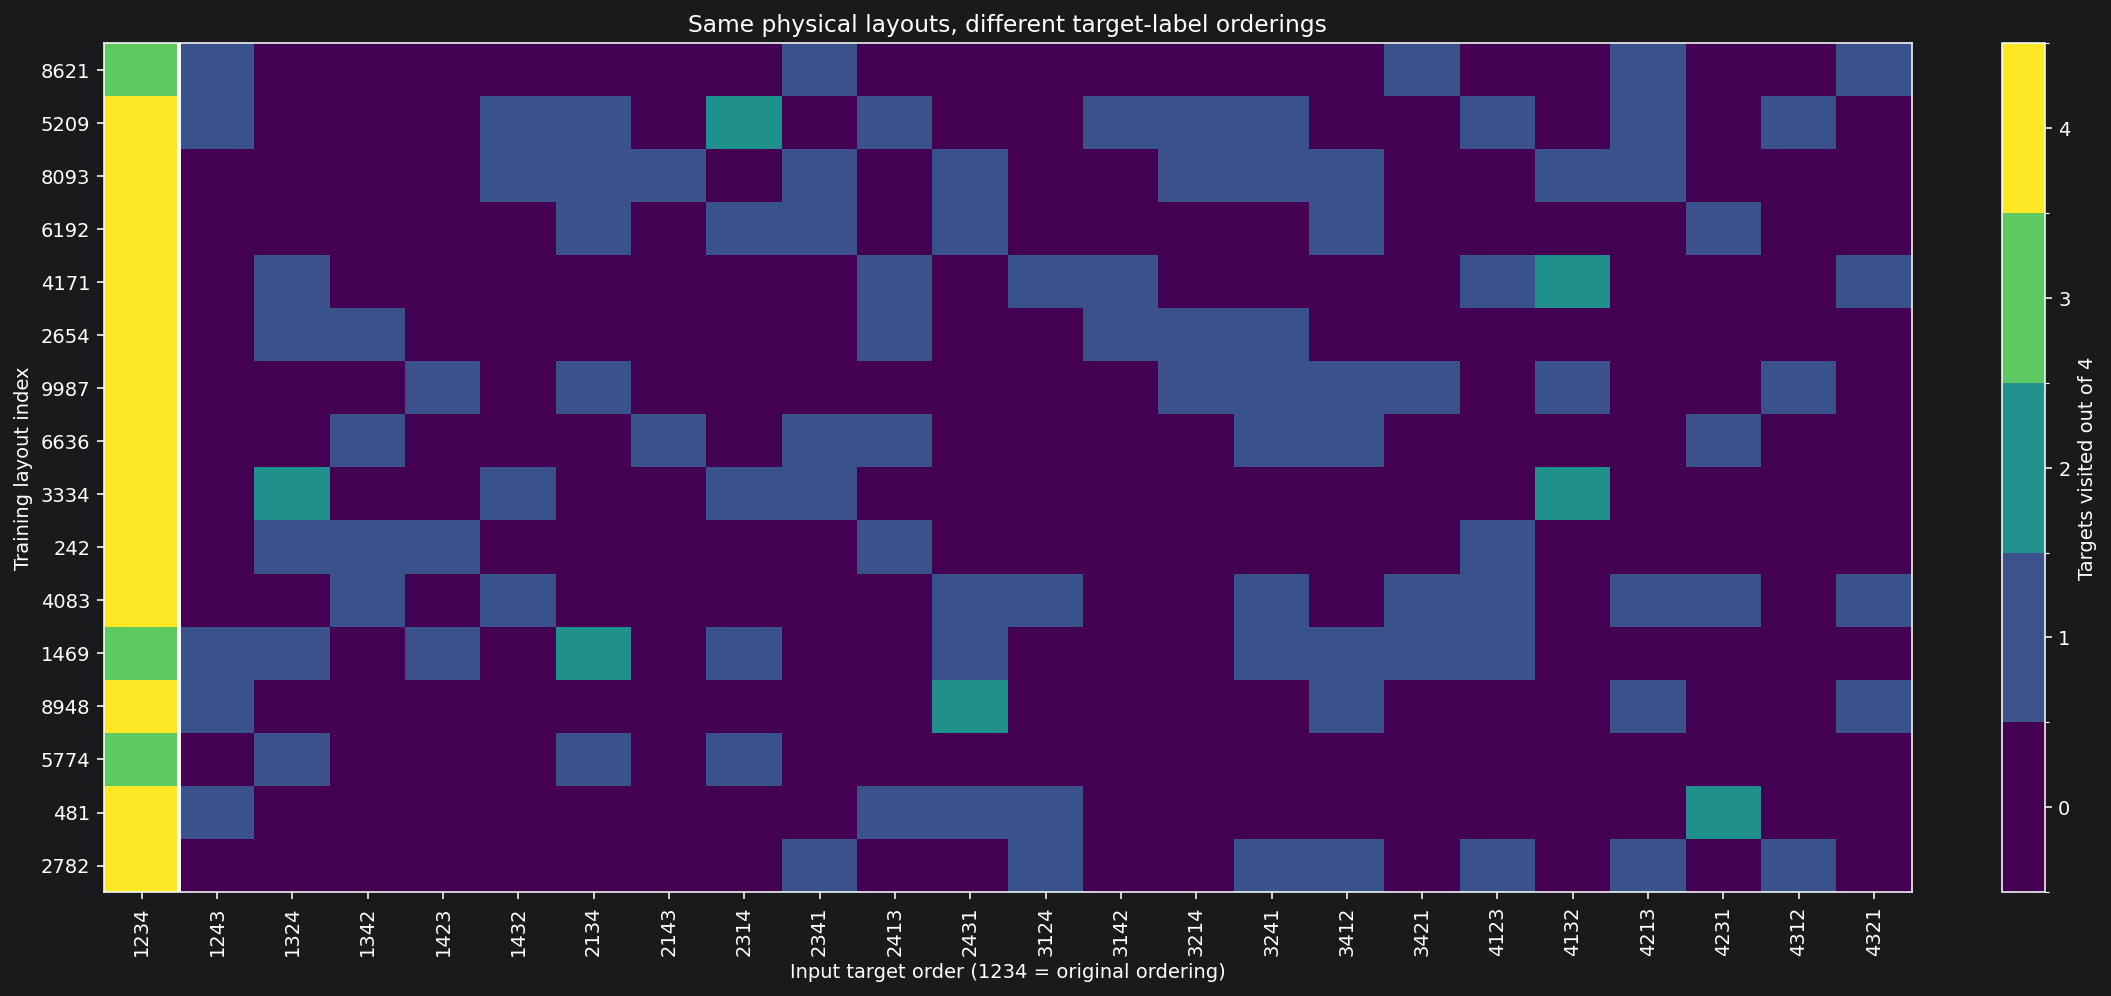

Saved: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/runs/sixteen_layout_fit_v1_seed0/permutation_check.npz


In [40]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm

fig, ax = plt.subplots(
    figsize=(15, 7),
    dpi=140,
    constrained_layout=True,
)

cmap = plt.get_cmap("viridis", 5)
norm = BoundaryNorm(np.arange(-0.5, 5.5, 1), cmap.N)

image = ax.imshow(
    permutation_counts.T,
    cmap=cmap,
    norm=norm,
    aspect="auto",
    interpolation="nearest",
)

ax.set_xticks(np.arange(num_permutations))
ax.set_xticklabels(
    [
        "".join(str(target + 1) for target in permutation)
        for permutation in box_permutations
    ],
    rotation=90,
)

ax.set_yticks(np.arange(num_layouts))
ax.set_yticklabels([
    str(index) for index in small_indices
])

ax.set_xlabel(
    "Input target order (1234 = original ordering)"
)
ax.set_ylabel("Training layout index")
ax.set_title(
    "Same physical layouts, different target-label orderings"
)

# Separate the original ordering from changed orderings.
ax.axvline(0.5, color="white", linewidth=2)

fig.colorbar(
    image,
    ax=ax,
    ticks=range(5),
    label="Targets visited out of 4",
)

plt.show()

np.savez_compressed(
    small_run_dir / "permutation_check.npz",
    permutations=box_permutations,
    layout_indices=small_indices,
    visited_counts=permutation_counts,
    target_distances_in_permuted_order=permutation_distances,
    mean_path_changes=mean_path_changes,
    paths=permutation_paths,
    ode_steps=np.array(evaluation_steps),
    visit_tolerance=np.array(evaluation_tolerance),
)

print("Saved:", small_run_dir / "permutation_check.npz")

In [41]:
def canonicalize_box_inputs(inputs):
    """
    Input columns:
      0:2   — current flow state a
      2:3   — tau
      3:5   — start position
      5:13  — four target coordinates

    Sort targets by x, then y.
    Leave a, tau and the start unchanged.
    """
    if inputs.ndim != 2 or inputs.shape[1] != 13:
        raise ValueError("Expected inputs with shape (B, 13).")

    boxes = inputs[:, 5:].reshape(-1, 4, 2)

    # Secondary key: y.
    order_y = torch.argsort(
        boxes[:, :, 1],
        dim=1,
        stable=True,
    )
    boxes = torch.gather(
        boxes,
        dim=1,
        index=order_y.unsqueeze(-1).expand(-1, -1, 2),
    )

    # Primary key: x; preserve y ordering when x is equal.
    order_x = torch.argsort(
        boxes[:, :, 0],
        dim=1,
        stable=True,
    )
    boxes = torch.gather(
        boxes,
        dim=1,
        index=order_x.unsqueeze(-1).expand(-1, -1, 2),
    )

    return torch.cat(
        [inputs[:, :5], boxes.reshape(-1, 8)],
        dim=1,
    )


class CanonicalConditionalVelocityMLP(ConditionalVelocityMLP):
    """Original MLP with target-coordinate sorting before normalization."""

    def forward(self, inputs):
        canonical_inputs = canonicalize_box_inputs(inputs)
        return super().forward(canonical_inputs)


# Verify all 24 label permutations produce identical canonical inputs.
check_batch = sample_flow_matching_batch(
    split=small_train_split,
    batch_size=32,
    rng=np.random.default_rng(1900),
)

check_inputs = torch.from_numpy(check_batch["inputs"])
canonical_reference = canonicalize_box_inputs(check_inputs)

for permutation in itertools.permutations(range(4)):
    reordered_inputs = check_inputs.clone()

    boxes = check_inputs[:, 5:].reshape(-1, 4, 2)
    reordered_inputs[:, 5:] = (
        boxes[:, list(permutation), :].reshape(-1, 8)
    )

    torch.testing.assert_close(
        canonicalize_box_inputs(reordered_inputs),
        canonical_reference,
        atol=0,
        rtol=0,
    )

# Check the tie-breaking rule explicitly.
tie_inputs = torch.zeros((1, 13), dtype=torch.float32)
tie_inputs[:, 5:] = torch.tensor([
    0.5, 0.8,
    0.2, 0.9,
    0.5, 0.1,
    0.2, 0.3,
])

expected_boxes = torch.tensor([[
    [0.2, 0.3],
    [0.2, 0.9],
    [0.5, 0.1],
    [0.5, 0.8],
]])

torch.testing.assert_close(
    canonicalize_box_inputs(tie_inputs)[:, 5:].reshape(1, 4, 2),
    expected_boxes,
    atol=0,
    rtol=0,
)

print("Checks passed: permutation invariance and coordinate tie-breaking.")

Checks passed: permutation invariance and coordinate tie-breaking.


In [42]:
from pathlib import Path
import copy
import json
import numpy as np
import torch

small_run_dir = (
    dataset_dir.parent.parent
    / "runs"
    / "sixteen_layout_canonical_fit_v1_seed0"
)

small_run_dir.mkdir(parents=True, exist_ok=True)

small_config = {
    "experiment": "sixteen_layout_canonical_fit_check",
    "input_preprocessing": "sort_targets_by_x_then_y",
    "dataset_dir": str(dataset_dir),
    "num_layouts": 16,
    "layout_selection_seed": 1600,
    "training_seed": 0,
    "train_sampling_seed": 1700,
    "validation_probe_seed": 1800,
    "validation_probe_size": 20_000,
    "num_epochs": 50,
    "steps_per_epoch": 100,
    "batch_size": 2048,
    "learning_rate": 1e-3,
    "weight_decay": 1e-6,
    "hidden_dim": 128,
    "num_hidden_layers": 4,
    "sigma_0": float(SIGMA_0),
    "stabilizing_gain": float(STABILIZING_GAIN),
}

config_path = small_run_dir / "config.json"
indices_path = small_run_dir / "layout_indices.npy"

if config_path.exists():
    stored_config = json.loads(
        config_path.read_text(encoding="utf-8")
    )
    if stored_config != small_config:
        raise ValueError(
            "Configuration differs from the existing run. "
            "Use a new run directory."
        )
else:
    config_path.write_text(
        json.dumps(small_config, indent=2),
        encoding="utf-8",
    )

expected_indices = np.random.default_rng(
    small_config["layout_selection_seed"]
).choice(
    len(task_splits["train"]["targets"]),
    size=small_config["num_layouts"],
    replace=False,
)

if indices_path.exists():
    small_indices = np.load(indices_path, allow_pickle=False)
    np.testing.assert_array_equal(small_indices, expected_indices)
else:
    small_indices = expected_indices
    np.save(indices_path, small_indices, allow_pickle=False)

small_train_split = {
    key: values[small_indices].copy()
    for key, values in task_splits["train"].items()
}

# Held-out (tau, noise) samples from the same 16 layouts.
# Used for checkpoint selection, not unseen-layout evaluation.
small_probe = sample_flow_matching_batch(
    split=small_train_split,
    batch_size=small_config["validation_probe_size"],
    rng=np.random.default_rng(
        small_config["validation_probe_seed"]
    ),
    sigma_0=small_config["sigma_0"],
    stabilizing_gain=small_config["stabilizing_gain"],
)

print("Selected training layout indices:")
print(small_indices)
print("Run directory:", small_run_dir)

Selected training layout indices:
[8621 5209 8093 6192 4171 2654 9987 6636 3334  242 4083 1469 8948 5774
  481 2782]
Run directory: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/runs/sixteen_layout_canonical_fit_v1_seed0


In [43]:
set_training_seed(small_config["training_seed"])

small_model = CanonicalConditionalVelocityMLP().to(
    device=device,
    dtype=torch.float32,
)

small_optimizer = torch.optim.AdamW(
    small_model.parameters(),
    lr=small_config["learning_rate"],
    weight_decay=small_config["weight_decay"],
)

small_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    small_optimizer,
    T_max=small_config["num_epochs"],
)

small_rng = np.random.default_rng(
    small_config["train_sampling_seed"]
)

probe_inputs = torch.from_numpy(
    small_probe["inputs"]
).to(device=device, dtype=torch.float32)

probe_targets = torch.from_numpy(
    small_probe["targets"]
).to(device=device, dtype=torch.float32)

small_history = {"train_loss": [], "probe_loss": []}
small_best_loss = float("inf")
small_best_epoch = None
small_start_epoch = 0

small_latest_path = small_run_dir / "latest.pt"
small_best_path = small_run_dir / "best.pt"

if small_latest_path.exists():
    checkpoint = torch.load(
        small_latest_path,
        map_location="cpu",
        weights_only=True,
    )

    small_model.load_state_dict(checkpoint["model"])
    small_optimizer.load_state_dict(checkpoint["optimizer"])
    small_scheduler.load_state_dict(checkpoint["scheduler"])

    small_rng.bit_generator.state = checkpoint["numpy_rng_state"]
    torch.set_rng_state(checkpoint["torch_rng_state"])

    if device.type == "cuda" and checkpoint["cuda_rng_states"]:
        torch.cuda.set_rng_state_all(checkpoint["cuda_rng_states"])

    small_history = checkpoint["history"]
    small_best_loss = checkpoint["best_loss"]
    small_best_epoch = checkpoint["best_epoch"]
    small_start_epoch = checkpoint["epoch"]

    print(f"Resuming after epoch {small_start_epoch}.")


def save_small_checkpoint(payload, path):
    temporary_path = path.with_suffix(".tmp")
    torch.save(payload, temporary_path)
    temporary_path.replace(path)


for epoch in range(
    small_start_epoch + 1,
    small_config["num_epochs"] + 1,
):
    small_model.train()
    train_loss_sum = 0.0

    for _ in range(small_config["steps_per_epoch"]):
        batch = sample_flow_matching_batch(
            split=small_train_split,
            batch_size=small_config["batch_size"],
            rng=small_rng,
            sigma_0=small_config["sigma_0"],
            stabilizing_gain=small_config["stabilizing_gain"],
        )

        inputs = torch.from_numpy(batch["inputs"]).to(device)
        targets = torch.from_numpy(batch["targets"]).to(device)

        small_optimizer.zero_grad(set_to_none=True)
        loss = torch.nn.functional.mse_loss(
            small_model(inputs), targets
        )

        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite training loss.")

        loss.backward()
        small_optimizer.step()
        train_loss_sum += loss.item()

    train_loss = (
        train_loss_sum / small_config["steps_per_epoch"]
    )

    small_model.eval()
    probe_loss_sum = 0.0

    with torch.no_grad():
        for offset in range(0, len(probe_inputs), 4096):
            inputs = probe_inputs[offset:offset + 4096]
            targets = probe_targets[offset:offset + 4096]

            loss = torch.nn.functional.mse_loss(
                small_model(inputs), targets
            )

            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite probe loss.")

            probe_loss_sum += loss.item() * len(inputs)

    probe_loss = probe_loss_sum / len(probe_inputs)

    small_history["train_loss"].append(train_loss)
    small_history["probe_loss"].append(probe_loss)

    state = {
        name: tensor.detach().cpu().clone()
        for name, tensor in small_model.state_dict().items()
    }

    if probe_loss < small_best_loss:
        small_best_loss = probe_loss
        small_best_epoch = epoch

        save_small_checkpoint(
            {
                "model": state,
                "epoch": epoch,
                "probe_loss": probe_loss,
                "config": small_config,
                "layout_indices": small_indices.tolist(),
            },
            small_best_path,
        )

    small_scheduler.step()

    save_small_checkpoint(
        {
            "model": state,
            "optimizer": small_optimizer.state_dict(),
            "scheduler": small_scheduler.state_dict(),
            "epoch": epoch,
            "history": copy.deepcopy(small_history),
            "best_loss": small_best_loss,
            "best_epoch": small_best_epoch,
            "numpy_rng_state": small_rng.bit_generator.state,
            "torch_rng_state": torch.get_rng_state(),
            "cuda_rng_states": (
                torch.cuda.get_rng_state_all()
                if device.type == "cuda" else []
            ),
        },
        small_latest_path,
    )

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:>3}/{small_config['num_epochs']} | "
            f"train={train_loss:.6f} | "
            f"same-layout probe={probe_loss:.6f} | "
            f"best epoch={small_best_epoch}"
        )

best_checkpoint = torch.load(
    small_best_path,
    map_location="cpu",
    weights_only=True,
)
small_model.load_state_dict(best_checkpoint["model"])
small_model.eval()

print(
    f"\nBest same-layout probe loss: "
    f"{best_checkpoint['probe_loss']:.6f} "
    f"(epoch {best_checkpoint['epoch']})"
)

Epoch   1/50 | train=0.646436 | same-layout probe=0.489879 | best epoch=1
Epoch   5/50 | train=0.160393 | same-layout probe=0.144296 | best epoch=5
Epoch  10/50 | train=0.086120 | same-layout probe=0.080790 | best epoch=10
Epoch  15/50 | train=0.059372 | same-layout probe=0.055505 | best epoch=15
Epoch  20/50 | train=0.046902 | same-layout probe=0.044560 | best epoch=20
Epoch  25/50 | train=0.039968 | same-layout probe=0.039058 | best epoch=25
Epoch  30/50 | train=0.036795 | same-layout probe=0.035553 | best epoch=30
Epoch  35/50 | train=0.034182 | same-layout probe=0.033026 | best epoch=35
Epoch  40/50 | train=0.032651 | same-layout probe=0.031856 | best epoch=40
Epoch  45/50 | train=0.031925 | same-layout probe=0.030980 | best epoch=45
Epoch  50/50 | train=0.031901 | same-layout probe=0.030822 | best epoch=49

Best same-layout probe loss: 0.030818 (epoch 49)


In [44]:
small_eval_model = copy.deepcopy(small_model).to(
    device=device,
    dtype=torch.float64,
)
small_eval_model.eval()

num_unseen_layouts = min(
    100, len(task_splits["validation"]["targets"])
)

small_unseen_split = {
    key: values[:num_unseen_layouts].copy()
    for key, values in task_splits["validation"].items()
}

small_evaluation = {}
small_evaluation_paths = {}

evaluation_steps = 1000
evaluation_tolerance = 0.02

for name, split in [
    ("Training-16", small_train_split),
    ("Validation-100", small_unseen_split),
]:
    paths = generate_validation_paths(
        small_eval_model,
        split,
        num_steps=evaluation_steps,
    )

    visits = summarize_path_visits(
        paths,
        split,
        evaluation_tolerance,
    )

    velocities = diagnose_velocity_fit(
        paths,
        split,
        small_eval_model,
    )

    summary = {
        "num_layouts": len(paths),
        "all_visited_rate": float(visits["all_visited_rate"]),
        "mean_visited": float(visits["mean_visited"]),
        "mean_worst_distance": float(visits["mean_worst_distance"]),
        "visit_count_histogram": np.bincount(
            visits["counts"], minlength=5
        ).tolist(),
        **velocities,
    }

    small_evaluation[name] = summary
    small_evaluation_paths[name] = paths

    np.savez_compressed(
        small_run_dir / f"{name}_rollouts.npz",
        paths=paths,
        starts=split["starts"],
        targets=split["targets"],
        target_distances=visits["distances"],
        visited_counts=visits["counts"],
    )

    print(f"\n{name}: {len(paths)} layouts")
    print(
        "  All four visited:",
        f"{summary['all_visited_rate']:.1%}",
    )
    print(
        "  Mean targets visited:",
        f"{summary['mean_visited']:.2f} / 4",
    )
    print(
        "  Mean worst-target distance:",
        f"{summary['mean_worst_distance']:.6f}",
    )
    print(
        "  Counts for visiting 0/1/2/3/4 targets:",
        summary["visit_count_histogram"],
    )
    print(
        "  Expert-path velocity RMSE:",
        f"{summary['expert_rmse']:.6f}",
    )
    print(
        "  Learned-path velocity RMSE:",
        f"{summary['rollout_rmse']:.6f}",
    )

evaluation_record = {
    "checkpoint_epoch": int(best_checkpoint["epoch"]),
    "ode_steps": evaluation_steps,
    "visit_tolerance": evaluation_tolerance,
    "initialization": "exact_start_without_noise",
    "validation_indices": list(range(num_unseen_layouts)),
    "results": small_evaluation,
}

(small_run_dir / "evaluation.json").write_text(
    json.dumps(evaluation_record, indent=2),
    encoding="utf-8",
)

print("\nEvaluation results saved.")


Training-16: 16 layouts
  All four visited: 93.8%
  Mean targets visited: 3.94 / 4
  Mean worst-target distance: 0.015435
  Counts for visiting 0/1/2/3/4 targets: [0, 0, 0, 1, 15]
  Expert-path velocity RMSE: 0.172030
  Learned-path velocity RMSE: 0.170885

Validation-100: 100 layouts
  All four visited: 0.0%
  Mean targets visited: 0.33 / 4
  Mean worst-target distance: 0.334008
  Counts for visiting 0/1/2/3/4 targets: [71, 25, 4, 0, 0]
  Expert-path velocity RMSE: 2.200379
  Learned-path velocity RMSE: 5.315228

Evaluation results saved.


In [45]:
@torch.no_grad()
def check_model_permutation_invariance(evaluation_model, split):
    batch = sample_flow_matching_batch(
        split=split,
        batch_size=256,
        rng=np.random.default_rng(2000),
    )

    parameter = next(evaluation_model.parameters())

    inputs = torch.as_tensor(
        batch["inputs"],
        dtype=parameter.dtype,
        device=parameter.device,
    )

    evaluation_model.eval()
    reference = evaluation_model(inputs)
    original_boxes = inputs[:, 5:].reshape(-1, 4, 2)

    max_difference = 0.0

    for permutation in itertools.permutations(range(4)):
        reordered = inputs.clone()
        reordered[:, 5:] = (
            original_boxes[:, list(permutation), :].reshape(-1, 8)
        )

        predicted = evaluation_model(reordered)

        difference = (
            predicted - reference
        ).abs().max().item()

        max_difference = max(max_difference, difference)

        torch.testing.assert_close(
            predicted,
            reference,
            atol=1e-10,
            rtol=1e-10,
        )

    return max_difference


max_difference = check_model_permutation_invariance(
    small_eval_model,
    small_train_split,
)

print(
    "Maximum velocity change across target permutations:",
    f"{max_difference:.3e}",
)
print("Check passed: target labels do not change model predictions.")

Maximum velocity change across target permutations: 0.000e+00
Check passed: target labels do not change model predictions.


In [46]:
import copy
import json
import numpy as np
import torch

full_sorted_dir = (
    dataset_dir.parent.parent
    / "runs"
    / "conditional_mlp_canonical_v1_seed0"
)
full_sorted_dir.mkdir(parents=True, exist_ok=True)

full_sorted_config = {
    "experiment": "full_dataset_canonical_conditioning",
    "dataset_dir": str(dataset_dir),
    "input_preprocessing": "sort_targets_by_x_then_y",
    "num_training_layouts": len(task_splits["train"]["targets"]),
    "training_seed": 0,
    "train_sampling_seed": 1000,
    "validation_probe_seed": 500,
    "validation_probe_size": 20_000,
    "num_epochs": 50,
    "steps_per_epoch": 100,
    "batch_size": 2048,
    "learning_rate": 1e-3,
    "weight_decay": 1e-6,
    "hidden_dim": 128,
    "num_hidden_layers": 4,
    "sigma_0": float(SIGMA_0),
    "stabilizing_gain": float(STABILIZING_GAIN),
}

full_config_path = full_sorted_dir / "config.json"

if full_config_path.exists():
    saved_config = json.loads(
        full_config_path.read_text(encoding="utf-8")
    )
    if saved_config != full_sorted_config:
        raise ValueError(
            "Existing run has a different configuration. "
            "Use a new run directory."
        )
else:
    full_config_path.write_text(
        json.dumps(full_sorted_config, indent=2),
        encoding="utf-8",
    )

# Same validation sampling seed as the original full-data experiment.
# Samples come from unseen validation layouts.
full_sorted_probe = sample_flow_matching_batch(
    split=task_splits["validation"],
    batch_size=full_sorted_config["validation_probe_size"],
    rng=np.random.default_rng(
        full_sorted_config["validation_probe_seed"]
    ),
    sigma_0=full_sorted_config["sigma_0"],
    stabilizing_gain=full_sorted_config["stabilizing_gain"],
)

full_val_inputs = torch.from_numpy(
    full_sorted_probe["inputs"]
).to(device=device, dtype=torch.float32)

full_val_targets = torch.from_numpy(
    full_sorted_probe["targets"]
).to(device=device, dtype=torch.float32)

print(
    "Training layouts:",
    full_sorted_config["num_training_layouts"],
)
print("Validation probe shape:", tuple(full_val_inputs.shape))
print("Run directory:", full_sorted_dir)

Training layouts: 10000
Validation probe shape: (20000, 13)
Run directory: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/runs/conditional_mlp_canonical_v1_seed0


In [47]:
set_training_seed(full_sorted_config["training_seed"])

full_sorted_model = CanonicalConditionalVelocityMLP().to(
    device=device,
    dtype=torch.float32,
)

full_optimizer = torch.optim.AdamW(
    full_sorted_model.parameters(),
    lr=full_sorted_config["learning_rate"],
    weight_decay=full_sorted_config["weight_decay"],
)

full_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    full_optimizer,
    T_max=full_sorted_config["num_epochs"],
)

full_rng = np.random.default_rng(
    full_sorted_config["train_sampling_seed"]
)

full_history = {
    "train_loss": [],
    "validation_loss": [],
}
full_best_loss = float("inf")
full_best_epoch = None
full_start_epoch = 0

full_latest_path = full_sorted_dir / "latest.pt"
full_best_path = full_sorted_dir / "best.pt"


def save_full_sorted_checkpoint(payload, path):
    temporary_path = path.with_suffix(".tmp")
    torch.save(payload, temporary_path)
    temporary_path.replace(path)


if full_latest_path.exists():
    checkpoint = torch.load(
        full_latest_path,
        map_location="cpu",
        weights_only=True,
    )

    full_sorted_model.load_state_dict(checkpoint["model"])
    full_optimizer.load_state_dict(checkpoint["optimizer"])
    full_scheduler.load_state_dict(checkpoint["scheduler"])

    full_rng.bit_generator.state = checkpoint["numpy_rng_state"]
    torch.set_rng_state(checkpoint["torch_rng_state"])

    if device.type == "cuda" and checkpoint["cuda_rng_states"]:
        torch.cuda.set_rng_state_all(checkpoint["cuda_rng_states"])

    full_history = checkpoint["history"]
    full_best_loss = checkpoint["best_loss"]
    full_best_epoch = checkpoint["best_epoch"]
    full_start_epoch = checkpoint["epoch"]

    print(f"Resuming after epoch {full_start_epoch}.")


for epoch in range(
    full_start_epoch + 1,
    full_sorted_config["num_epochs"] + 1,
):
    full_sorted_model.train()
    train_loss_sum = 0.0

    for _ in range(full_sorted_config["steps_per_epoch"]):
        batch = sample_flow_matching_batch(
            split=task_splits["train"],
            batch_size=full_sorted_config["batch_size"],
            rng=full_rng,
            sigma_0=full_sorted_config["sigma_0"],
            stabilizing_gain=full_sorted_config["stabilizing_gain"],
        )

        inputs = torch.from_numpy(batch["inputs"]).to(device)
        targets = torch.from_numpy(batch["targets"]).to(device)

        full_optimizer.zero_grad(set_to_none=True)

        loss = torch.nn.functional.mse_loss(
            full_sorted_model(inputs), targets
        )

        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite training loss.")

        loss.backward()
        full_optimizer.step()

        train_loss_sum += loss.item()

    train_loss = (
        train_loss_sum / full_sorted_config["steps_per_epoch"]
    )

    full_sorted_model.eval()
    validation_loss_sum = 0.0

    with torch.no_grad():
        for offset in range(0, len(full_val_inputs), 4096):
            inputs = full_val_inputs[offset:offset + 4096]
            targets = full_val_targets[offset:offset + 4096]

            loss = torch.nn.functional.mse_loss(
                full_sorted_model(inputs), targets
            )

            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite validation loss.")

            validation_loss_sum += loss.item() * len(inputs)

    validation_loss = (
        validation_loss_sum / len(full_val_inputs)
    )

    full_history["train_loss"].append(train_loss)
    full_history["validation_loss"].append(validation_loss)

    model_state = {
        name: tensor.detach().cpu().clone()
        for name, tensor in full_sorted_model.state_dict().items()
    }

    if validation_loss < full_best_loss:
        full_best_loss = validation_loss
        full_best_epoch = epoch

        save_full_sorted_checkpoint(
            {
                "model": model_state,
                "epoch": epoch,
                "validation_loss": validation_loss,
                "config": full_sorted_config,
            },
            full_best_path,
        )

    full_scheduler.step()

    save_full_sorted_checkpoint(
        {
            "model": model_state,
            "optimizer": full_optimizer.state_dict(),
            "scheduler": full_scheduler.state_dict(),
            "epoch": epoch,
            "history": copy.deepcopy(full_history),
            "best_loss": full_best_loss,
            "best_epoch": full_best_epoch,
            "numpy_rng_state": full_rng.bit_generator.state,
            "torch_rng_state": torch.get_rng_state(),
            "cuda_rng_states": (
                torch.cuda.get_rng_state_all()
                if device.type == "cuda" else []
            ),
        },
        full_latest_path,
    )

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:>3}/{full_sorted_config['num_epochs']} | "
            f"train={train_loss:.6f} | "
            f"validation={validation_loss:.6f} | "
            f"best epoch={full_best_epoch}"
        )

full_best_checkpoint = torch.load(
    full_best_path,
    map_location="cpu",
    weights_only=True,
)

full_sorted_model.load_state_dict(full_best_checkpoint["model"])
full_sorted_model.eval()

print(
    "\nBest validation loss:",
    f"{full_best_checkpoint['validation_loss']:.6f}",
    f"(epoch {full_best_checkpoint['epoch']})",
)

Epoch   1/50 | train=0.602732 | validation=0.514852 | best epoch=1
Epoch   5/50 | train=0.372073 | validation=0.355536 | best epoch=5
Epoch  10/50 | train=0.280273 | validation=0.271855 | best epoch=10
Epoch  15/50 | train=0.228655 | validation=0.224241 | best epoch=15
Epoch  20/50 | train=0.194079 | validation=0.189929 | best epoch=20
Epoch  25/50 | train=0.173578 | validation=0.170335 | best epoch=25
Epoch  30/50 | train=0.158556 | validation=0.157721 | best epoch=30
Epoch  35/50 | train=0.151801 | validation=0.151924 | best epoch=35
Epoch  40/50 | train=0.147158 | validation=0.146470 | best epoch=40
Epoch  45/50 | train=0.143781 | validation=0.145055 | best epoch=45
Epoch  50/50 | train=0.143949 | validation=0.144603 | best epoch=47

Best validation loss: 0.144602 (epoch 47)


In [48]:
original_run_dir = (
    dataset_dir.parent.parent
    / "runs"
    / "conditional_mlp_v1_seed0"
)

original_checkpoint = torch.load(
    original_run_dir / "best.pt",
    map_location="cpu",
    weights_only=True,
)

original_eval_model = ConditionalVelocityMLP().to(
    device=device,
    dtype=torch.float64,
)
original_eval_model.load_state_dict(original_checkpoint["model"])
original_eval_model.eval()

full_sorted_eval_model = copy.deepcopy(full_sorted_model).to(
    device=device,
    dtype=torch.float64,
)
full_sorted_eval_model.eval()

# Reproduce the original diagnostic layout selection.
comparison_num_train = min(
    100,
    len(task_splits["train"]["targets"]),
    len(task_splits["validation"]["targets"]),
)
comparison_train_indices = np.random.default_rng(600).choice(
    len(task_splits["train"]["targets"]),
    size=comparison_num_train,
    replace=False,
)

comparison_num_validation = min(
    100, len(task_splits["validation"]["targets"])
)
comparison_validation_indices = np.arange(
    comparison_num_validation
)

comparison_splits = {
    "Training": {
        key: values[comparison_train_indices].copy()
        for key, values in task_splits["train"].items()
    },
    "Validation": {
        key: values[comparison_validation_indices].copy()
        for key, values in task_splits["validation"].items()
    },
}

comparison_steps = 1000
comparison_tolerance = 0.02
full_comparison = {}

for model_name, evaluation_model in [
    ("Original", original_eval_model),
    ("Sorted", full_sorted_eval_model),
]:
    full_comparison[model_name] = {}

    for split_name, split in comparison_splits.items():
        print(f"Evaluating {model_name} on {split_name} layouts...")

        paths = generate_validation_paths(
            evaluation_model,
            split,
            num_steps=comparison_steps,
        )

        visits = summarize_path_visits(
            paths,
            split,
            comparison_tolerance,
        )

        velocity_metrics = diagnose_velocity_fit(
            paths,
            split,
            evaluation_model,
        )

        summary = {
            "num_layouts": len(paths),
            "all_visited_rate": float(visits["all_visited_rate"]),
            "mean_visited": float(visits["mean_visited"]),
            "mean_worst_distance": float(
                visits["mean_worst_distance"]
            ),
            "visit_count_histogram": np.bincount(
                visits["counts"], minlength=5
            ).tolist(),
            **velocity_metrics,
        }

        full_comparison[model_name][split_name] = summary

        np.savez_compressed(
            full_sorted_dir / f"{model_name}_{split_name}_rollouts.npz",
            paths=paths,
            starts=split["starts"],
            targets=split["targets"],
            target_distances=visits["distances"],
            visited_counts=visits["counts"],
        )

print(
    f"\n{'Model':>10} {'Layouts':>12} "
    f"{'All 4':>9} {'Mean visits':>12} "
    f"{'Worst dist':>12} {'Expert RMSE':>13} "
    f"{'Rollout RMSE':>14}"
)

for model_name, split_results in full_comparison.items():
    for split_name, result in split_results.items():
        print(
            f"{model_name:>10} {split_name:>12} "
            f"{result['all_visited_rate']:>8.1%} "
            f"{result['mean_visited']:>9.2f}/4 "
            f"{result['mean_worst_distance']:>12.6f} "
            f"{result['expert_rmse']:>13.6f} "
            f"{result['rollout_rmse']:>14.6f}"
        )

record = {
    "original_checkpoint_epoch": int(original_checkpoint["epoch"]),
    "sorted_checkpoint_epoch": int(full_best_checkpoint["epoch"]),
    "train_indices": comparison_train_indices.tolist(),
    "validation_indices": comparison_validation_indices.tolist(),
    "ode_steps": comparison_steps,
    "visit_tolerance": comparison_tolerance,
    "initialization": "exact_start_without_noise",
    "results": full_comparison,
}

(full_sorted_dir / "comparison.json").write_text(
    json.dumps(record, indent=2),
    encoding="utf-8",
)

print("\nComparison saved.")

Evaluating Original on Training layouts...
Evaluating Original on Validation layouts...
Evaluating Sorted on Training layouts...
Evaluating Sorted on Validation layouts...

     Model      Layouts     All 4  Mean visits   Worst dist   Expert RMSE   Rollout RMSE
  Original     Training     0.0%      0.41/4     0.195329      0.531661       0.791646
  Original   Validation     0.0%      0.36/4     0.192085      0.540926       0.805977
    Sorted     Training     3.0%      1.22/4     0.139198      0.359818       0.636381
    Sorted   Validation     5.0%      1.21/4     0.145750      0.364038       0.634431

Comparison saved.
